In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import MNIST
from torchvision import transforms
from scipy.stats import wasserstein_distance
import torchvision
import math

In [2]:
# 设置随机种子以获得可重复结果
torch.manual_seed(42)
np.random.seed(42)

# 检查GPU可用性
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 加载MNIST数据集
transform = transforms.Compose([
    transforms.ToTensor(),
])

# 加载训练和测试数据
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=60, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=60, shuffle=False)

Using device: cuda:0


Training data shapes: X=torch.Size([10000, 1, 28, 28]), y=torch.Size([10000])
Testing data shapes: X=torch.Size([60, 1, 28, 28]), y=torch.Size([60])


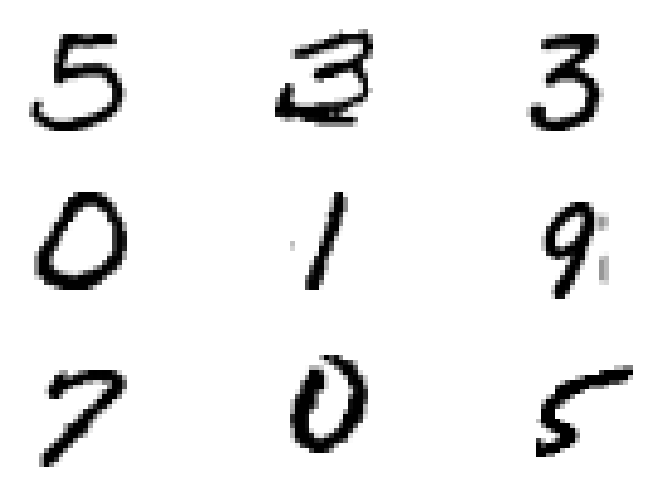

In [3]:
# 获取一些样本数据以进行可视化
trainX = []
trainY = []

for images, labels in train_loader:
    trainX.append(images)
    trainY.append(labels)
    if len(trainX) * images.shape[0] >= 10000:  # 只取前10000个图像
        break

trainX = torch.cat(trainX, dim=0)[:10000]  # 取前10000个图像
trainY = torch.cat(trainY, dim=0)[:10000]  # 取前10000个标签

print('Training data shapes: X=%s, y=%s' % (trainX.shape, trainY.shape))
testX = next(iter(test_loader))[0]
testY = next(iter(test_loader))[1]
print('Testing data shapes: X=%s, y=%s' % (testX.shape, testY.shape))

# 可视化一些训练图像
for k in range(1):  # 只显示一组图像，避免显示过多
    plt.figure(figsize=(9, 6))
    for j in range(9):
        i = np.random.randint(0, 10000)
        plt.subplot(3, 3, j+1)
        plt.imshow(trainX[i][0], cmap='gray_r')  # 索引[0]获取通道维度
        plt.axis('off')
    plt.show()


In [31]:
#自定义激活函数
#添加1.1
#1.SiLU、GELU、CauchyLU
#class CustomActivation(nn.Module):
#    def __init__(self):
#        super(CustomActivation, self).__init__()
#        self.sigma = nn.Parameter(torch.tensor(0.103))
#    def forward(self, input):
#        #temp = input*torch.sigmoid(input/self.sigma) #SiLU
#        temp = input/2*(1+torch.erf(input/math.sqrt(2)/self.sigma)) #GELU
#        #temp = input * ((1/math.pi) * torch.atan(input / torch.abs(self.sigma)) + 0.5) #CauchyLU
#        return temp
#结束1.1

#添加2.1
#class ExLU(nn.Module): 
class RayLU(nn.Module): 
#class LaplaceLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.sigma = nn.Parameter(torch.ones(1) * 0.1)  # 初始化为0.1
    
    def forward(self, input):
        positive_sigma = torch.abs(self.sigma)  # 确保sigma为正
        
        # 创建掩码
        positive_mask = (input >= 0)
        negative_mask = ~positive_mask
        
        result = torch.zeros_like(input)
        # x ≥ 0 的情况：直接返回x #ExLU、RayLU
        result[positive_mask] = input[positive_mask] #ExLU、RayLU
        # x ≥ 0 的情况：x * (1 - 0.5 * exp(-x/σ)) #LaplaceLU
        #result[positive_mask] = input[positive_mask] * (1 - 0.5 * torch.exp(-input[positive_mask] / positive_sigma)) #LaplaceLU
        # x < 0 的情况：x * exp(x/σ) #ExLU 
#        result[negative_mask] = input[negative_mask] * torch.exp(input[negative_mask]/positive_sigma) #ExLU
        # x < 0 的情况：x * exp(-x²/(2*σ²)) #RayLU
        result[negative_mask] = input[negative_mask] * torch.exp(-input[negative_mask]**2/(2*positive_sigma**2)) #RayLU
        # x < 0 的情况：x * (0.5 * exp(x/σ)) #LaplaceLU
#        result[negative_mask] = input[negative_mask] * (0.5 * torch.exp(input[negative_mask] / positive_sigma)) #LaplaceLU        
        
        return result
#结束2.1

In [32]:
# 定义生成器网络
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(100, 64),
            #nn.ReLU(True),
            #添加1.2
            #CustomActivation(),
            #结束1.2

            #添加2.2
            #LaplaceLU(),
            #ExLU(),
            RayLU(),
            #结束2.2
            nn.Linear(64, 28*28),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.main(x)
        return x.view(-1, 1, 28, 28)  # 调整形状为 (batch_size, 1, 28, 28)

# 定义判别器网络
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 64),
            #nn.ReLU(),
            #添加1.3
            #CustomActivation(),
            #结束1.3

            #添加2.3
            #LaplaceLU(),
            #ExLU(),
            RayLU(),
            #结束2.3
            
            nn.Linear(64, 1),
        )
        self.sigmoid = nn.Sigmoid()

         # 可学习参数sigma
        self.min_sigma = 0.08
        self.max_sigma = 0.2
        raw_init = -math.log((self.max_sigma - 0.1) / (0.1 - self.min_sigma))
        self.raw_sigma = nn.Parameter(torch.tensor(raw_init))

    def get_sigma(self):
        return self.min_sigma + (self.max_sigma - self.min_sigma) * torch.sigmoid(self.raw_sigma)

    def forward(self, x):
        output = self.main(x)
        sigma = self.get_sigma()
        output = self.sigmoid(output / sigma)
        return output, sigma  # 返回判别器输出和sigma值

In [33]:
# 初始化网络
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# 打印网络结构
print(generator)
print(discriminator)

# 定义损失函数和优化器
criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_d = optim.Adam([
    {'params': [p for n, p in discriminator.named_parameters() if n != 'raw_sigma'], 'lr': 0.0001},
    {'params': [discriminator.raw_sigma], 'lr': 0.00001}
], betas=(0.5, 0.999))

# 生成随机噪声
#def get_random_noise(batch_size, noise_size):
#    return torch.randn(batch_size, noise_size, device=device)

# 获取假样本
def get_fake_samples(generator, batch_size):
    random_noise_batch = torch.randn(batch_size, 100, device=device)  # 生成随机噪声向量
    fake_samples = generator(random_noise_batch)
    return fake_samples

# 获取真实样本
def get_real_samples(batch_size):
    random_indices = np.random.choice(range(len(trainX)), size=batch_size)
    real_images = trainX[random_indices].to(device)
    return real_images

# 展示生成器结果
def show_generator_results(generator):
    generator.eval()  # 设置为评估模式
    fake_samples = get_fake_samples(generator, 9)  # 获取假样本
    fake_samples = fake_samples.detach().cpu()  # 将张量从GPU转移到CPU
    fake_samples = fake_samples.numpy()  # 转换为NumPy数组
    # 调整图像形状以适合imshow显示
    # 假设图像是单通道的（例如MNIST数据集），形状为 (batch_size, 1, height, width)
    fake_samples = fake_samples.squeeze(1)  # 去掉通道维度
    plt.figure(figsize=(9, 6))
    for j in range(9):
        plt.subplot(3, 3, j+1)
        plt.imshow(fake_samples[j], cmap='gray_r')  # 显示图像
        plt.axis('off')
    plt.show()
    generator.train()  # 恢复为训练模式

Generator(
  (main): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): RayLU()
    (2): Linear(in_features=64, out_features=784, bias=True)
    (3): Sigmoid()
  )
)
Discriminator(
  (main): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): RayLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
  (sigmoid): Sigmoid()
)


In [34]:
# 训练参数
epochs = 500
batch_size = 60
steps = 50  # 在每个epoch中的训练步数
#noise_size = 2
#noise_std = 0.05
#noise_std_min = 0.01
#noise_std_max = 0.2
#noise_increase_factor = 1.05
#noise_decrease_factor = 0.95
#noise_change_threshold = 1e-3

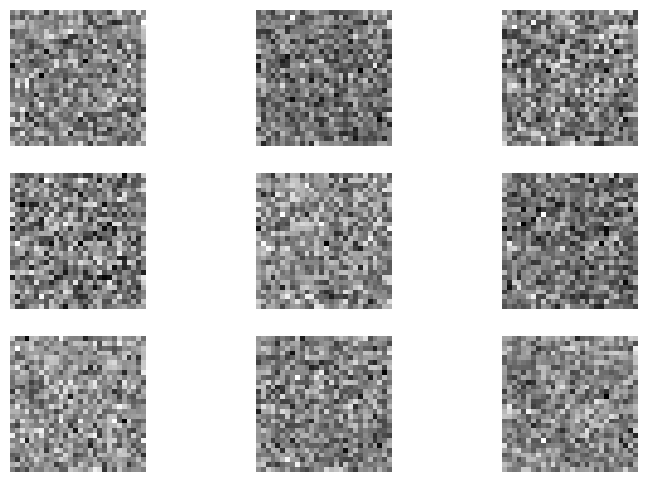

Epoch:0, D-Loss:0.071, D-Acc:100.000, G-Loss:4.343, Sigma:0.1000
Epoch:1, D-Loss:0.022, D-Acc:100.000, G-Loss:5.356, Sigma:0.1000
Epoch:2, D-Loss:0.012, D-Acc:100.000, G-Loss:5.831, Sigma:0.1000
Epoch:3, D-Loss:0.011, D-Acc:100.000, G-Loss:6.169, Sigma:0.1000
Epoch:4, D-Loss:0.007, D-Acc:100.000, G-Loss:6.785, Sigma:0.1000


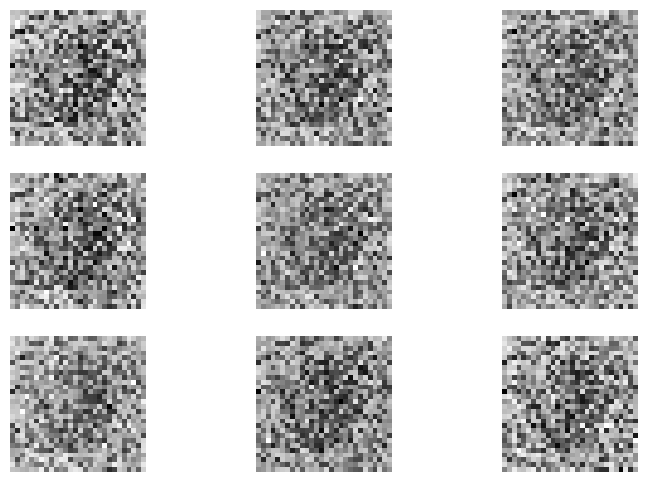

Epoch:5, D-Loss:0.006, D-Acc:100.000, G-Loss:6.954, Sigma:0.1000
Epoch:6, D-Loss:0.008, D-Acc:100.000, G-Loss:7.848, Sigma:0.1000
Epoch:7, D-Loss:0.005, D-Acc:100.000, G-Loss:7.615, Sigma:0.1000
Epoch:8, D-Loss:0.009, D-Acc:100.000, G-Loss:7.628, Sigma:0.1000
Epoch:9, D-Loss:0.003, D-Acc:100.000, G-Loss:7.815, Sigma:0.1000


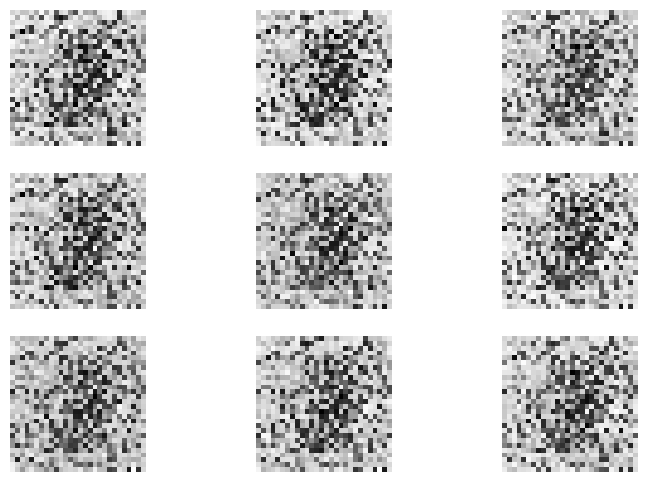

Epoch:10, D-Loss:0.002, D-Acc:100.000, G-Loss:7.778, Sigma:0.1000
Epoch:11, D-Loss:0.003, D-Acc:100.000, G-Loss:7.545, Sigma:0.1000
Epoch:12, D-Loss:0.005, D-Acc:100.000, G-Loss:7.831, Sigma:0.1000
Epoch:13, D-Loss:0.006, D-Acc:100.000, G-Loss:7.982, Sigma:0.1000
Epoch:14, D-Loss:0.003, D-Acc:100.000, G-Loss:8.258, Sigma:0.1000


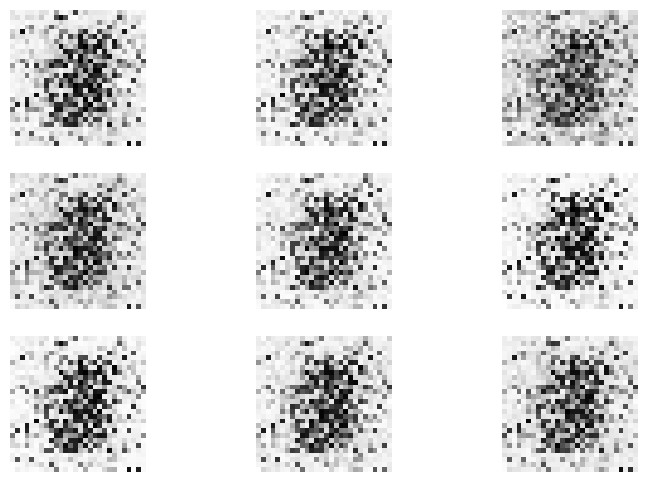

Epoch:15, D-Loss:0.004, D-Acc:100.000, G-Loss:8.352, Sigma:0.1000
Epoch:16, D-Loss:0.006, D-Acc:100.000, G-Loss:8.295, Sigma:0.1000
Epoch:17, D-Loss:0.003, D-Acc:100.000, G-Loss:7.722, Sigma:0.1000
Epoch:18, D-Loss:0.009, D-Acc:100.000, G-Loss:8.371, Sigma:0.1000
Epoch:19, D-Loss:0.008, D-Acc:100.000, G-Loss:7.679, Sigma:0.0999


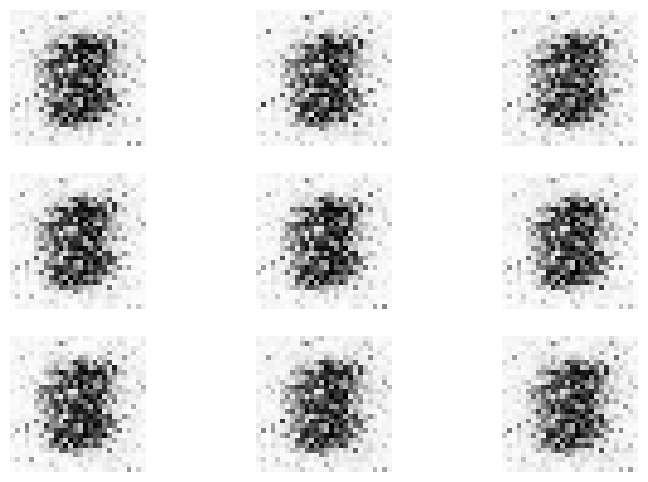

Epoch:20, D-Loss:0.019, D-Acc:100.000, G-Loss:6.656, Sigma:0.0999
Epoch:21, D-Loss:0.016, D-Acc:100.000, G-Loss:6.789, Sigma:0.0999
Epoch:22, D-Loss:0.029, D-Acc:100.000, G-Loss:6.637, Sigma:0.0999
Epoch:23, D-Loss:0.029, D-Acc:100.000, G-Loss:4.841, Sigma:0.0999
Epoch:24, D-Loss:0.055, D-Acc:100.000, G-Loss:4.738, Sigma:0.0999


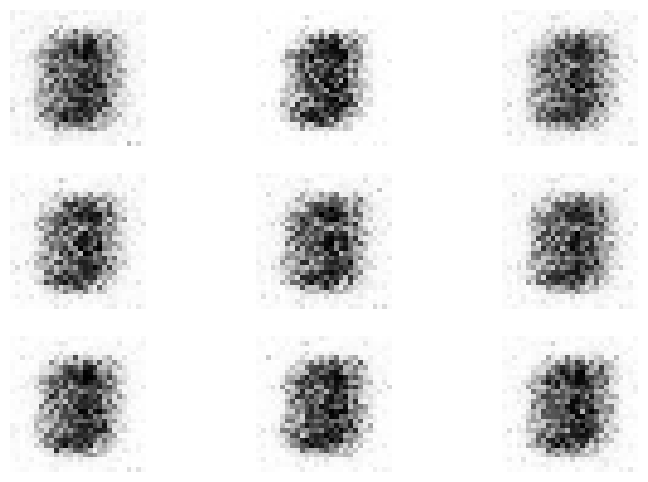

Epoch:25, D-Loss:0.059, D-Acc:100.000, G-Loss:5.051, Sigma:0.0999
Epoch:26, D-Loss:0.058, D-Acc:100.000, G-Loss:4.732, Sigma:0.0999
Epoch:27, D-Loss:0.055, D-Acc:100.000, G-Loss:5.207, Sigma:0.0998
Epoch:28, D-Loss:0.070, D-Acc:100.000, G-Loss:4.439, Sigma:0.0998
Epoch:29, D-Loss:0.073, D-Acc:98.333, G-Loss:4.102, Sigma:0.0998


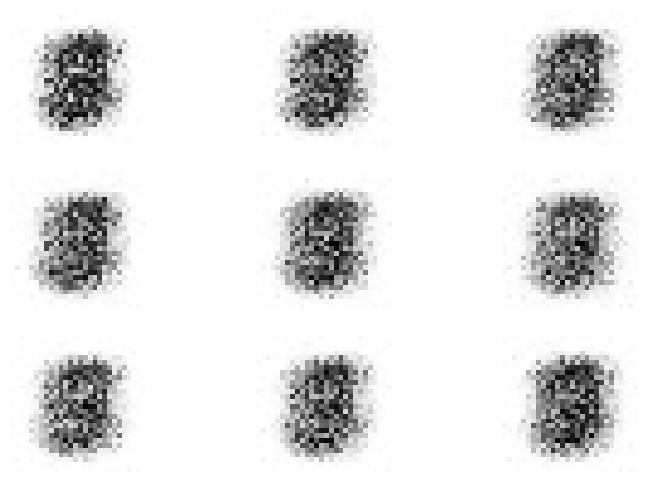

Epoch:30, D-Loss:0.069, D-Acc:98.333, G-Loss:4.348, Sigma:0.0998
Epoch:31, D-Loss:0.031, D-Acc:100.000, G-Loss:4.783, Sigma:0.0998
Epoch:32, D-Loss:0.028, D-Acc:100.000, G-Loss:5.181, Sigma:0.0998
Epoch:33, D-Loss:0.023, D-Acc:100.000, G-Loss:4.127, Sigma:0.0998
Epoch:34, D-Loss:0.027, D-Acc:100.000, G-Loss:4.594, Sigma:0.0998


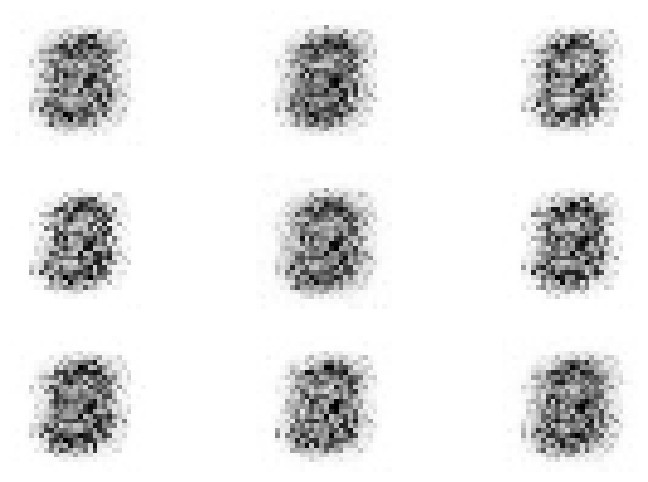

Epoch:35, D-Loss:0.018, D-Acc:100.000, G-Loss:5.091, Sigma:0.0998
Epoch:36, D-Loss:0.014, D-Acc:100.000, G-Loss:5.062, Sigma:0.0998
Epoch:37, D-Loss:0.023, D-Acc:100.000, G-Loss:4.758, Sigma:0.0998
Epoch:38, D-Loss:0.047, D-Acc:98.333, G-Loss:4.885, Sigma:0.0998
Epoch:39, D-Loss:0.014, D-Acc:100.000, G-Loss:5.333, Sigma:0.0998


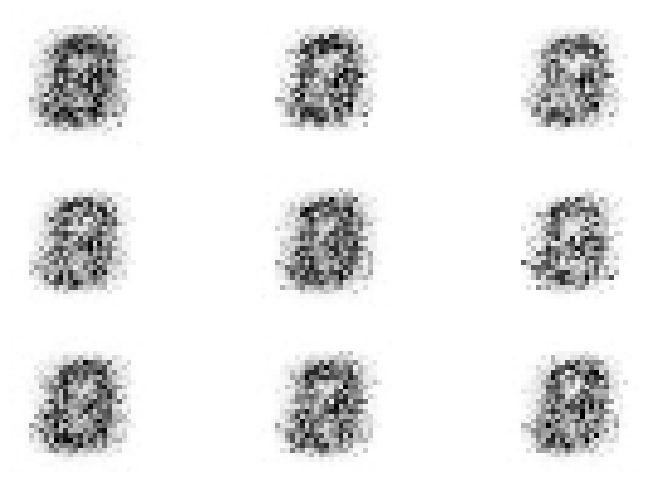

Epoch:40, D-Loss:0.029, D-Acc:100.000, G-Loss:4.478, Sigma:0.0997
Epoch:41, D-Loss:0.048, D-Acc:100.000, G-Loss:4.535, Sigma:0.0997
Epoch:42, D-Loss:0.035, D-Acc:100.000, G-Loss:4.209, Sigma:0.0997
Epoch:43, D-Loss:0.040, D-Acc:100.000, G-Loss:4.478, Sigma:0.0997
Epoch:44, D-Loss:0.039, D-Acc:100.000, G-Loss:4.500, Sigma:0.0997


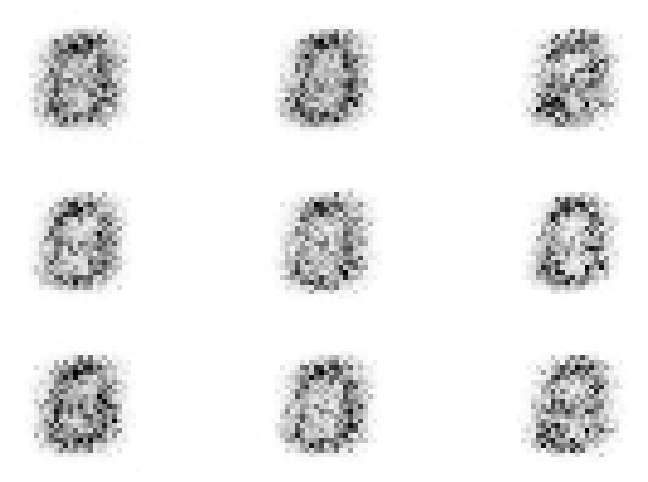

Epoch:45, D-Loss:0.029, D-Acc:100.000, G-Loss:4.024, Sigma:0.0997
Epoch:46, D-Loss:0.024, D-Acc:100.000, G-Loss:4.336, Sigma:0.0997
Epoch:47, D-Loss:0.022, D-Acc:100.000, G-Loss:4.505, Sigma:0.0997
Epoch:48, D-Loss:0.070, D-Acc:98.333, G-Loss:3.677, Sigma:0.0997
Epoch:49, D-Loss:0.096, D-Acc:98.333, G-Loss:4.222, Sigma:0.0997


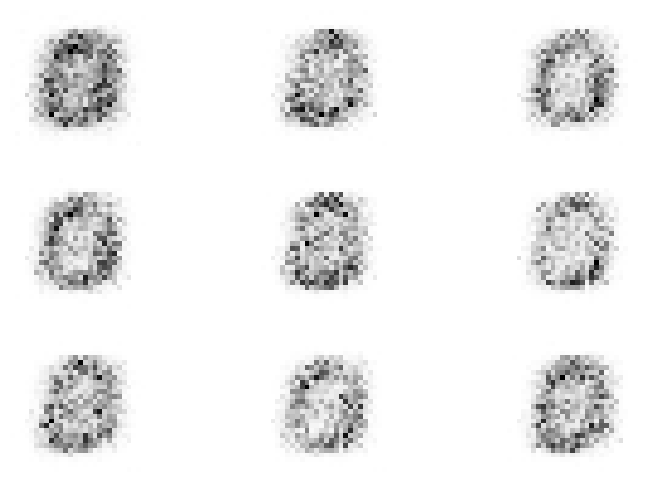

Epoch:50, D-Loss:0.056, D-Acc:98.333, G-Loss:4.554, Sigma:0.0997
Epoch:51, D-Loss:0.054, D-Acc:98.333, G-Loss:4.425, Sigma:0.0997
Epoch:52, D-Loss:0.020, D-Acc:100.000, G-Loss:4.447, Sigma:0.0997
Epoch:53, D-Loss:0.035, D-Acc:100.000, G-Loss:4.711, Sigma:0.0997
Epoch:54, D-Loss:0.038, D-Acc:100.000, G-Loss:4.747, Sigma:0.0996


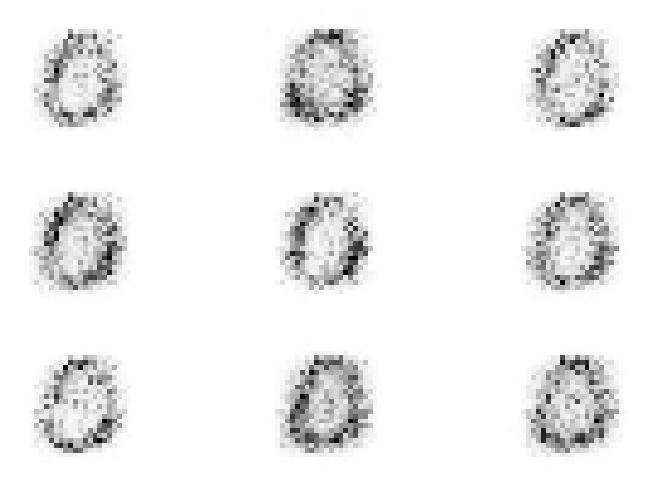

Epoch:55, D-Loss:0.022, D-Acc:100.000, G-Loss:4.646, Sigma:0.0996
Epoch:56, D-Loss:0.035, D-Acc:100.000, G-Loss:4.948, Sigma:0.0996
Epoch:57, D-Loss:0.039, D-Acc:100.000, G-Loss:4.991, Sigma:0.0996
Epoch:58, D-Loss:0.046, D-Acc:98.333, G-Loss:5.082, Sigma:0.0996
Epoch:59, D-Loss:0.047, D-Acc:100.000, G-Loss:5.092, Sigma:0.0996


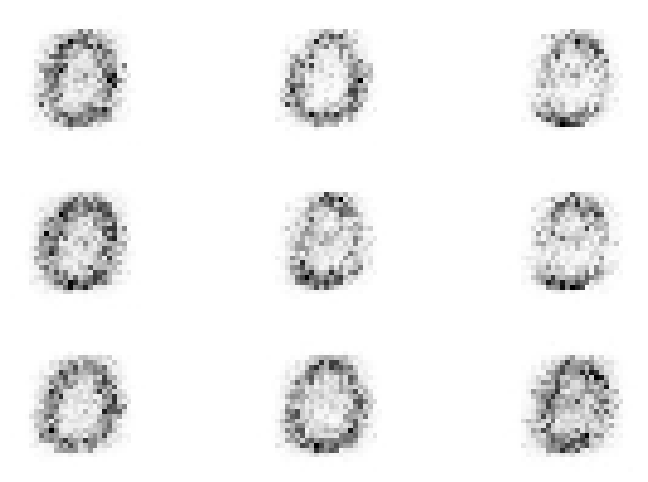

Epoch:60, D-Loss:0.015, D-Acc:100.000, G-Loss:4.654, Sigma:0.0996
Epoch:61, D-Loss:0.020, D-Acc:100.000, G-Loss:5.201, Sigma:0.0996
Epoch:62, D-Loss:0.040, D-Acc:100.000, G-Loss:5.083, Sigma:0.0996
Epoch:63, D-Loss:0.020, D-Acc:100.000, G-Loss:5.086, Sigma:0.0996
Epoch:64, D-Loss:0.027, D-Acc:100.000, G-Loss:5.394, Sigma:0.0996


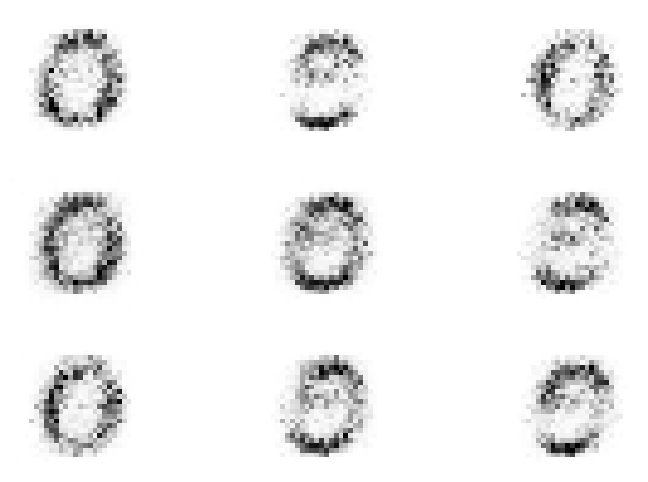

Epoch:65, D-Loss:0.076, D-Acc:98.333, G-Loss:4.472, Sigma:0.0996
Epoch:66, D-Loss:0.016, D-Acc:100.000, G-Loss:5.329, Sigma:0.0996
Epoch:67, D-Loss:0.016, D-Acc:100.000, G-Loss:5.421, Sigma:0.0996
Epoch:68, D-Loss:0.009, D-Acc:100.000, G-Loss:5.426, Sigma:0.0996
Epoch:69, D-Loss:0.012, D-Acc:100.000, G-Loss:5.205, Sigma:0.0996


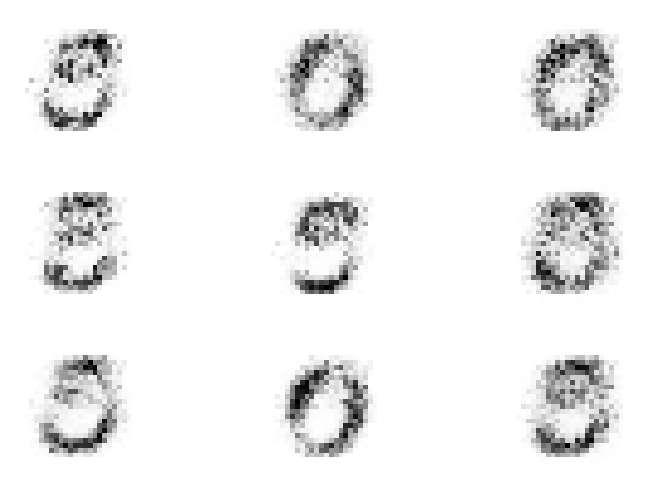

Epoch:70, D-Loss:0.015, D-Acc:100.000, G-Loss:5.072, Sigma:0.0996
Epoch:71, D-Loss:0.012, D-Acc:100.000, G-Loss:5.865, Sigma:0.0995
Epoch:72, D-Loss:0.037, D-Acc:100.000, G-Loss:5.086, Sigma:0.0995
Epoch:73, D-Loss:0.054, D-Acc:98.333, G-Loss:5.319, Sigma:0.0995
Epoch:74, D-Loss:0.016, D-Acc:100.000, G-Loss:5.479, Sigma:0.0995


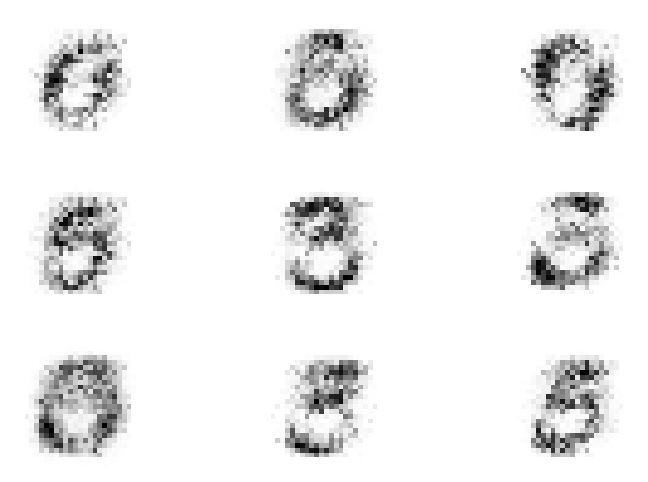

Epoch:75, D-Loss:0.042, D-Acc:100.000, G-Loss:5.501, Sigma:0.0995
Epoch:76, D-Loss:0.044, D-Acc:100.000, G-Loss:4.869, Sigma:0.0995
Epoch:77, D-Loss:0.039, D-Acc:100.000, G-Loss:5.143, Sigma:0.0995
Epoch:78, D-Loss:0.022, D-Acc:100.000, G-Loss:5.988, Sigma:0.0995
Epoch:79, D-Loss:0.020, D-Acc:100.000, G-Loss:5.431, Sigma:0.0995


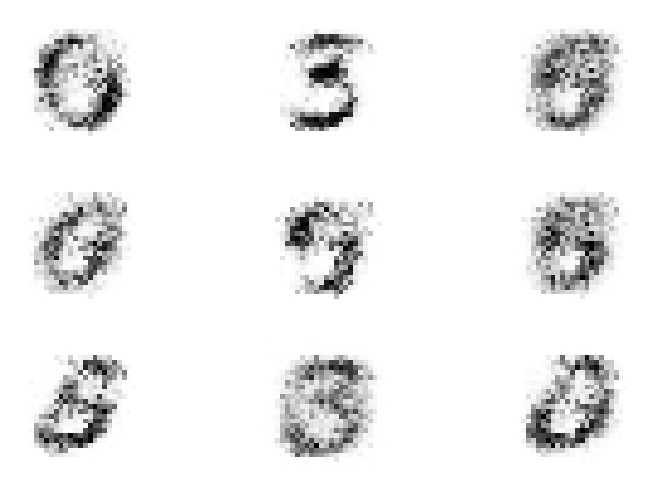

Epoch:80, D-Loss:0.030, D-Acc:100.000, G-Loss:5.443, Sigma:0.0995
Epoch:81, D-Loss:0.048, D-Acc:100.000, G-Loss:5.559, Sigma:0.0995
Epoch:82, D-Loss:0.032, D-Acc:100.000, G-Loss:5.375, Sigma:0.0995
Epoch:83, D-Loss:0.170, D-Acc:98.333, G-Loss:5.498, Sigma:0.0995
Epoch:84, D-Loss:0.021, D-Acc:100.000, G-Loss:5.294, Sigma:0.0994


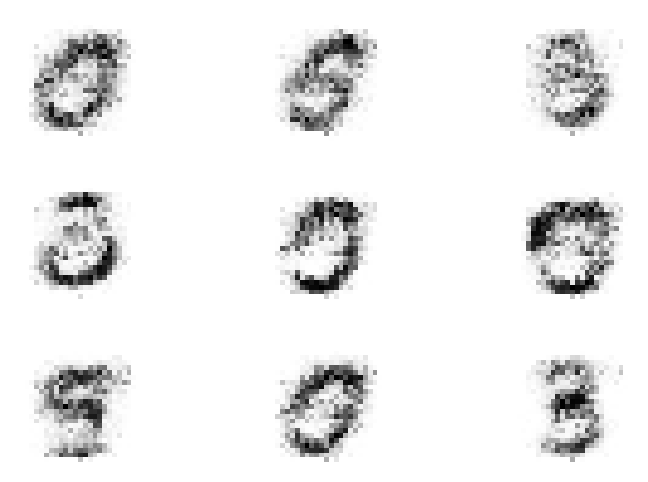

Epoch:85, D-Loss:0.116, D-Acc:96.667, G-Loss:4.507, Sigma:0.0994
Epoch:86, D-Loss:0.055, D-Acc:100.000, G-Loss:4.277, Sigma:0.0994
Epoch:87, D-Loss:0.054, D-Acc:100.000, G-Loss:5.040, Sigma:0.0994
Epoch:88, D-Loss:0.133, D-Acc:96.667, G-Loss:4.659, Sigma:0.0994
Epoch:89, D-Loss:0.068, D-Acc:98.333, G-Loss:5.293, Sigma:0.0994


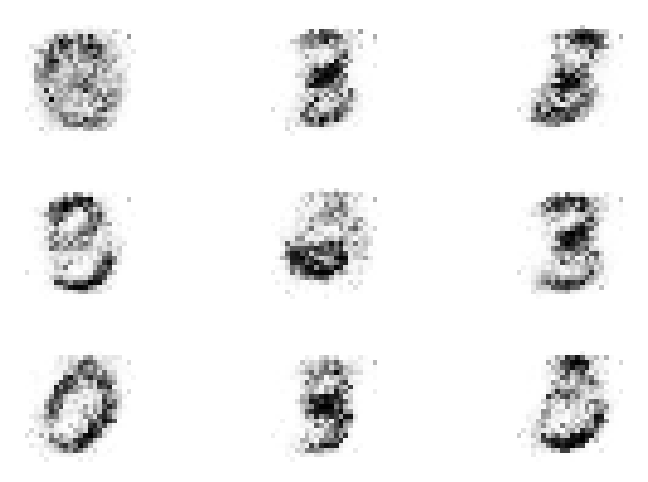

Epoch:90, D-Loss:0.064, D-Acc:100.000, G-Loss:5.019, Sigma:0.0994
Epoch:91, D-Loss:0.094, D-Acc:98.333, G-Loss:4.319, Sigma:0.0994
Epoch:92, D-Loss:0.125, D-Acc:98.333, G-Loss:4.687, Sigma:0.0994
Epoch:93, D-Loss:0.060, D-Acc:100.000, G-Loss:5.035, Sigma:0.0994
Epoch:94, D-Loss:0.087, D-Acc:98.333, G-Loss:4.948, Sigma:0.0993


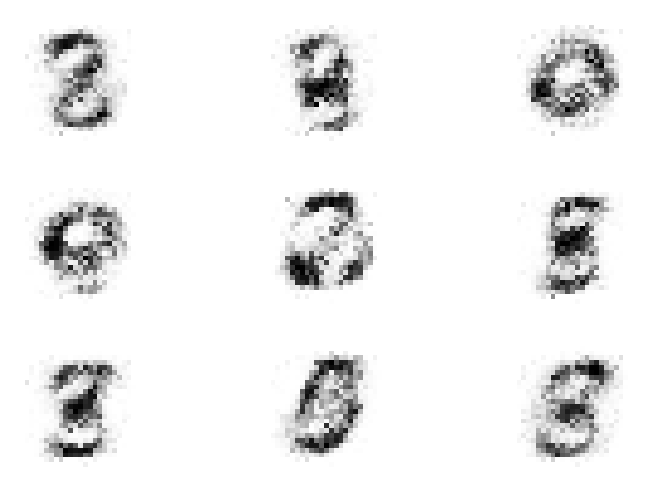

Epoch:95, D-Loss:0.065, D-Acc:100.000, G-Loss:4.721, Sigma:0.0993
Epoch:96, D-Loss:0.091, D-Acc:98.333, G-Loss:4.516, Sigma:0.0993
Epoch:97, D-Loss:0.038, D-Acc:100.000, G-Loss:4.888, Sigma:0.0993
Epoch:98, D-Loss:0.056, D-Acc:100.000, G-Loss:4.595, Sigma:0.0993
Epoch:99, D-Loss:0.048, D-Acc:100.000, G-Loss:4.852, Sigma:0.0993


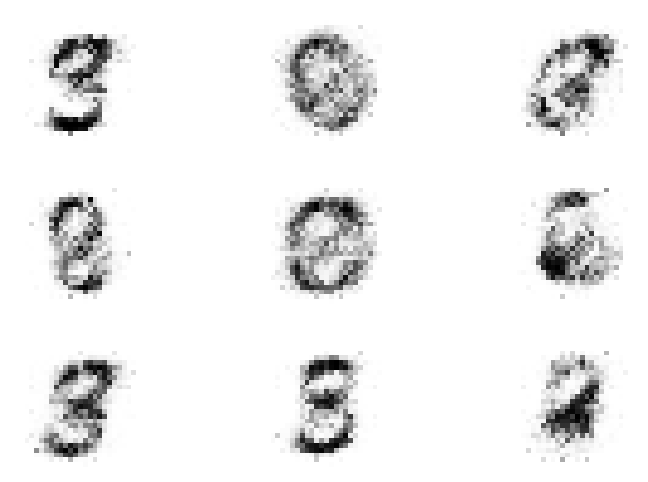

Epoch:100, D-Loss:0.062, D-Acc:100.000, G-Loss:4.424, Sigma:0.0993
Epoch:101, D-Loss:0.058, D-Acc:100.000, G-Loss:5.022, Sigma:0.0993
Epoch:102, D-Loss:0.055, D-Acc:100.000, G-Loss:4.977, Sigma:0.0993
Epoch:103, D-Loss:0.056, D-Acc:100.000, G-Loss:4.986, Sigma:0.0993
Epoch:104, D-Loss:0.049, D-Acc:100.000, G-Loss:4.417, Sigma:0.0993


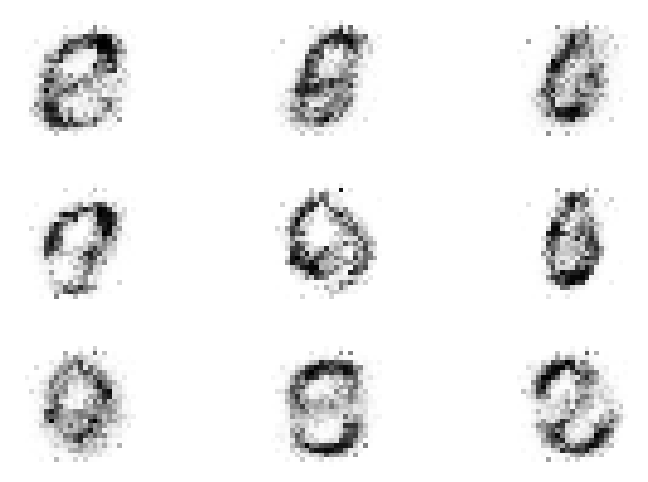

Epoch:105, D-Loss:0.061, D-Acc:100.000, G-Loss:4.949, Sigma:0.0992
Epoch:106, D-Loss:0.075, D-Acc:98.333, G-Loss:5.075, Sigma:0.0992
Epoch:107, D-Loss:0.124, D-Acc:98.333, G-Loss:4.895, Sigma:0.0992
Epoch:108, D-Loss:0.060, D-Acc:100.000, G-Loss:5.184, Sigma:0.0992
Epoch:109, D-Loss:0.111, D-Acc:98.333, G-Loss:4.442, Sigma:0.0992


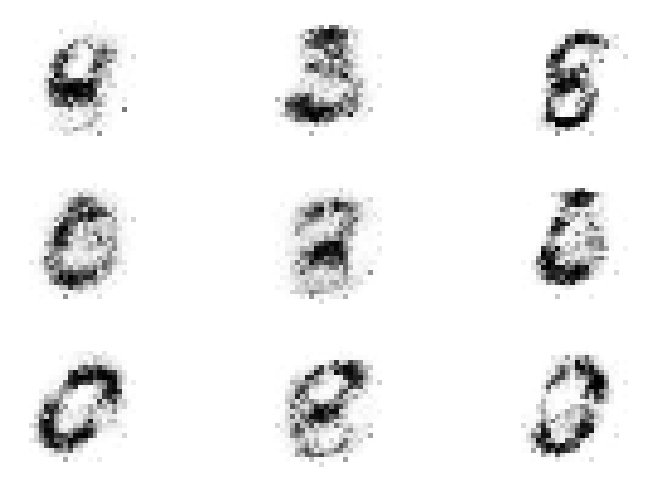

Epoch:110, D-Loss:0.162, D-Acc:98.333, G-Loss:4.458, Sigma:0.0992
Epoch:111, D-Loss:0.113, D-Acc:98.333, G-Loss:5.042, Sigma:0.0992
Epoch:112, D-Loss:0.085, D-Acc:98.333, G-Loss:5.054, Sigma:0.0992
Epoch:113, D-Loss:0.062, D-Acc:100.000, G-Loss:4.244, Sigma:0.0992
Epoch:114, D-Loss:0.050, D-Acc:100.000, G-Loss:4.758, Sigma:0.0992


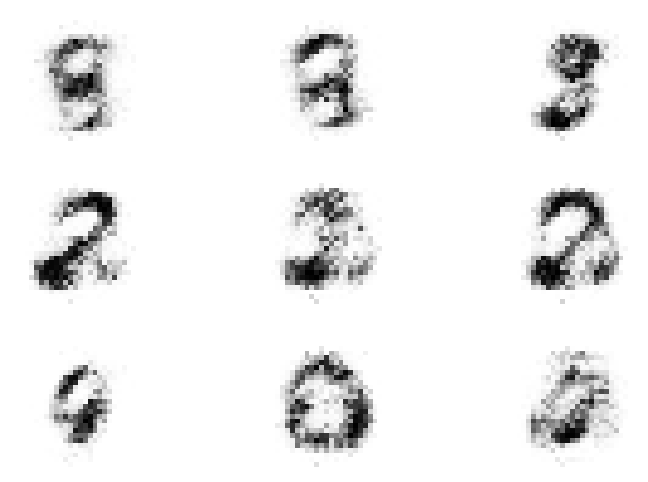

Epoch:115, D-Loss:0.152, D-Acc:98.333, G-Loss:4.276, Sigma:0.0992
Epoch:116, D-Loss:0.073, D-Acc:100.000, G-Loss:4.473, Sigma:0.0992
Epoch:117, D-Loss:0.098, D-Acc:96.667, G-Loss:4.221, Sigma:0.0992
Epoch:118, D-Loss:0.065, D-Acc:100.000, G-Loss:5.017, Sigma:0.0991
Epoch:119, D-Loss:0.073, D-Acc:100.000, G-Loss:4.856, Sigma:0.0991


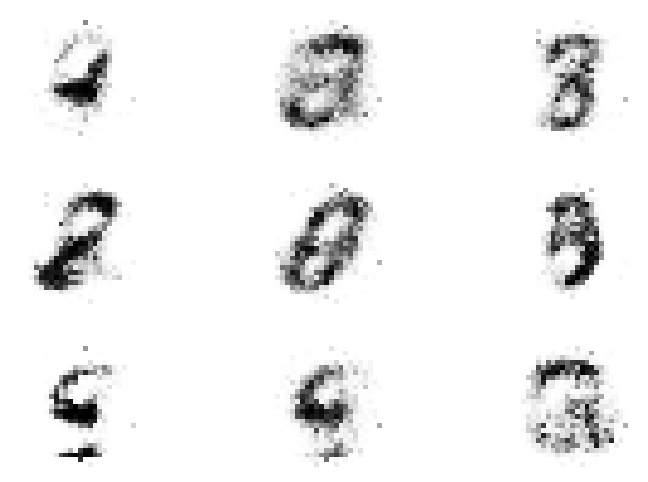

Epoch:120, D-Loss:0.267, D-Acc:96.667, G-Loss:4.503, Sigma:0.0991
Epoch:121, D-Loss:0.122, D-Acc:98.333, G-Loss:4.041, Sigma:0.0991
Epoch:122, D-Loss:0.167, D-Acc:96.667, G-Loss:4.321, Sigma:0.0991
Epoch:123, D-Loss:0.159, D-Acc:96.667, G-Loss:4.795, Sigma:0.0991
Epoch:124, D-Loss:0.075, D-Acc:98.333, G-Loss:4.494, Sigma:0.0991


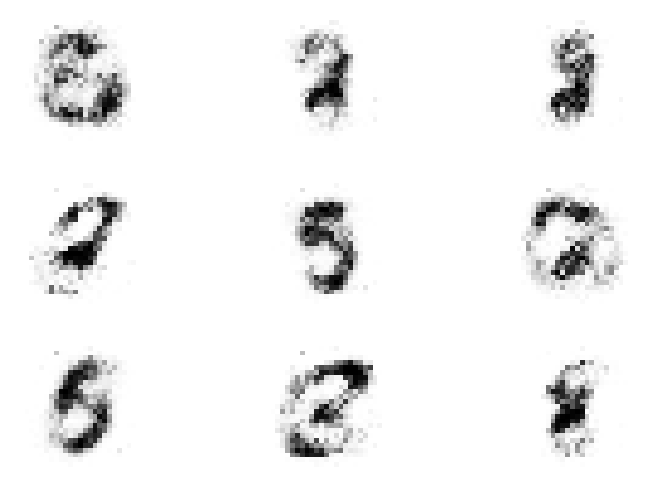

Epoch:125, D-Loss:0.163, D-Acc:96.667, G-Loss:5.082, Sigma:0.0991
Epoch:126, D-Loss:0.106, D-Acc:98.333, G-Loss:4.973, Sigma:0.0991
Epoch:127, D-Loss:0.061, D-Acc:100.000, G-Loss:4.069, Sigma:0.0991
Epoch:128, D-Loss:0.204, D-Acc:96.667, G-Loss:4.601, Sigma:0.0991
Epoch:129, D-Loss:0.066, D-Acc:100.000, G-Loss:4.607, Sigma:0.0991


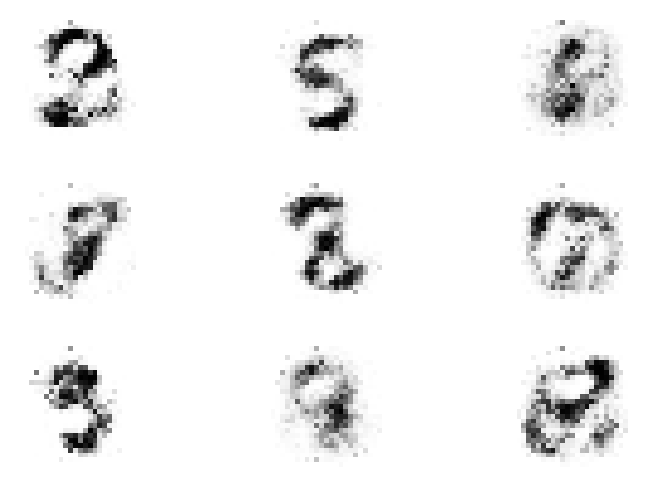

Epoch:130, D-Loss:0.079, D-Acc:100.000, G-Loss:3.895, Sigma:0.0990
Epoch:131, D-Loss:0.127, D-Acc:96.667, G-Loss:4.264, Sigma:0.0990
Epoch:132, D-Loss:0.058, D-Acc:100.000, G-Loss:4.233, Sigma:0.0990
Epoch:133, D-Loss:0.096, D-Acc:98.333, G-Loss:4.588, Sigma:0.0990
Epoch:134, D-Loss:0.118, D-Acc:100.000, G-Loss:4.392, Sigma:0.0990


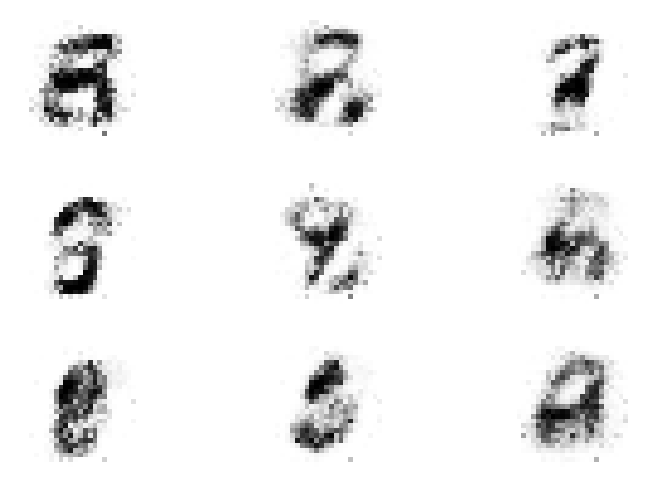

Epoch:135, D-Loss:0.139, D-Acc:96.667, G-Loss:4.015, Sigma:0.0990
Epoch:136, D-Loss:0.088, D-Acc:98.333, G-Loss:4.035, Sigma:0.0990
Epoch:137, D-Loss:0.083, D-Acc:100.000, G-Loss:3.722, Sigma:0.0990
Epoch:138, D-Loss:0.111, D-Acc:98.333, G-Loss:4.454, Sigma:0.0990
Epoch:139, D-Loss:0.160, D-Acc:98.333, G-Loss:3.872, Sigma:0.0990


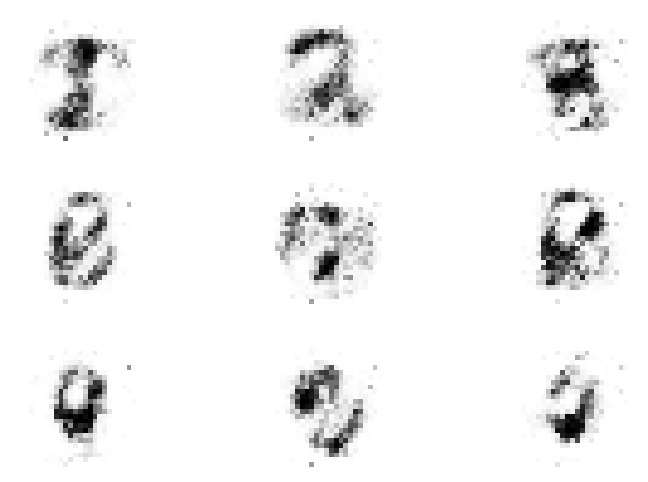

Epoch:140, D-Loss:0.110, D-Acc:100.000, G-Loss:4.637, Sigma:0.0990
Epoch:141, D-Loss:0.188, D-Acc:96.667, G-Loss:3.871, Sigma:0.0990
Epoch:142, D-Loss:0.326, D-Acc:93.333, G-Loss:3.717, Sigma:0.0989
Epoch:143, D-Loss:0.136, D-Acc:96.667, G-Loss:3.971, Sigma:0.0989
Epoch:144, D-Loss:0.210, D-Acc:98.333, G-Loss:4.607, Sigma:0.0989


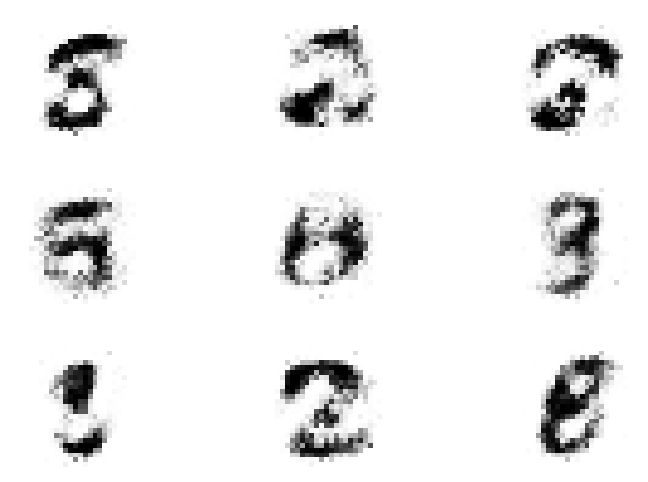

Epoch:145, D-Loss:0.087, D-Acc:100.000, G-Loss:4.131, Sigma:0.0989
Epoch:146, D-Loss:0.103, D-Acc:100.000, G-Loss:3.929, Sigma:0.0989
Epoch:147, D-Loss:0.165, D-Acc:98.333, G-Loss:4.588, Sigma:0.0989
Epoch:148, D-Loss:0.246, D-Acc:98.333, G-Loss:4.494, Sigma:0.0989
Epoch:149, D-Loss:0.125, D-Acc:96.667, G-Loss:3.594, Sigma:0.0989


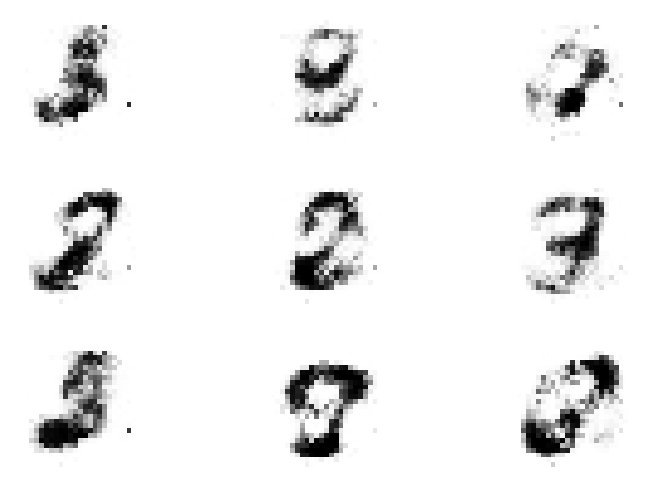

Epoch:150, D-Loss:0.185, D-Acc:96.667, G-Loss:4.328, Sigma:0.0989
Epoch:151, D-Loss:0.103, D-Acc:98.333, G-Loss:4.038, Sigma:0.0989
Epoch:152, D-Loss:0.196, D-Acc:96.667, G-Loss:4.329, Sigma:0.0989
Epoch:153, D-Loss:0.359, D-Acc:91.667, G-Loss:3.938, Sigma:0.0989
Epoch:154, D-Loss:0.158, D-Acc:95.000, G-Loss:3.842, Sigma:0.0989


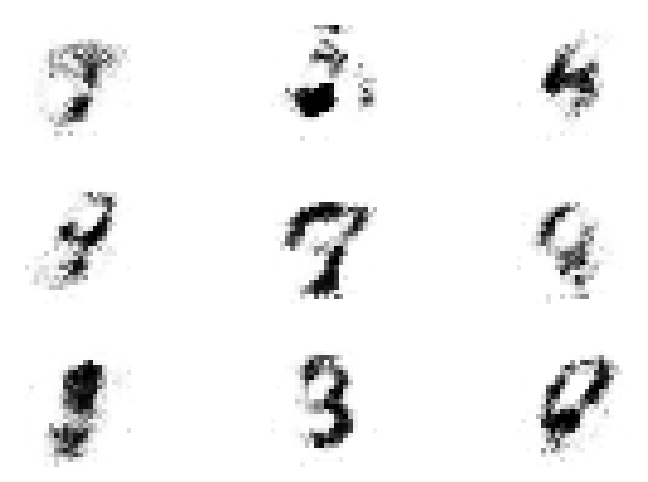

Epoch:155, D-Loss:0.133, D-Acc:96.667, G-Loss:4.170, Sigma:0.0989
Epoch:156, D-Loss:0.194, D-Acc:96.667, G-Loss:5.007, Sigma:0.0988
Epoch:157, D-Loss:0.156, D-Acc:98.333, G-Loss:3.317, Sigma:0.0988
Epoch:158, D-Loss:0.150, D-Acc:100.000, G-Loss:4.172, Sigma:0.0988
Epoch:159, D-Loss:0.183, D-Acc:96.667, G-Loss:3.641, Sigma:0.0988


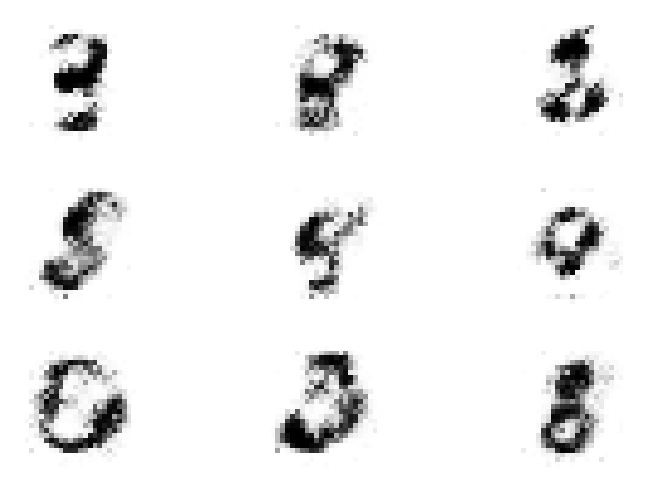

Epoch:160, D-Loss:0.117, D-Acc:100.000, G-Loss:3.805, Sigma:0.0988
Epoch:161, D-Loss:0.119, D-Acc:96.667, G-Loss:3.917, Sigma:0.0988
Epoch:162, D-Loss:0.160, D-Acc:96.667, G-Loss:3.643, Sigma:0.0988
Epoch:163, D-Loss:0.367, D-Acc:93.333, G-Loss:3.998, Sigma:0.0988
Epoch:164, D-Loss:0.266, D-Acc:93.333, G-Loss:4.423, Sigma:0.0988


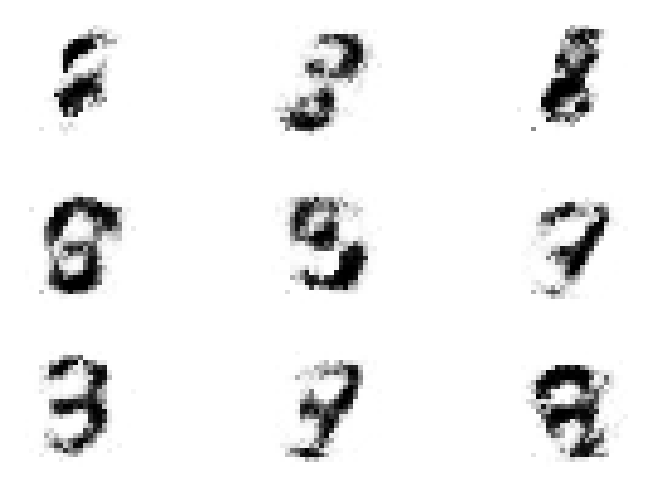

Epoch:165, D-Loss:0.363, D-Acc:93.333, G-Loss:4.299, Sigma:0.0988
Epoch:166, D-Loss:0.331, D-Acc:93.333, G-Loss:3.892, Sigma:0.0988
Epoch:167, D-Loss:0.264, D-Acc:95.000, G-Loss:4.379, Sigma:0.0988
Epoch:168, D-Loss:0.414, D-Acc:93.333, G-Loss:4.064, Sigma:0.0988
Epoch:169, D-Loss:0.450, D-Acc:90.000, G-Loss:4.152, Sigma:0.0988


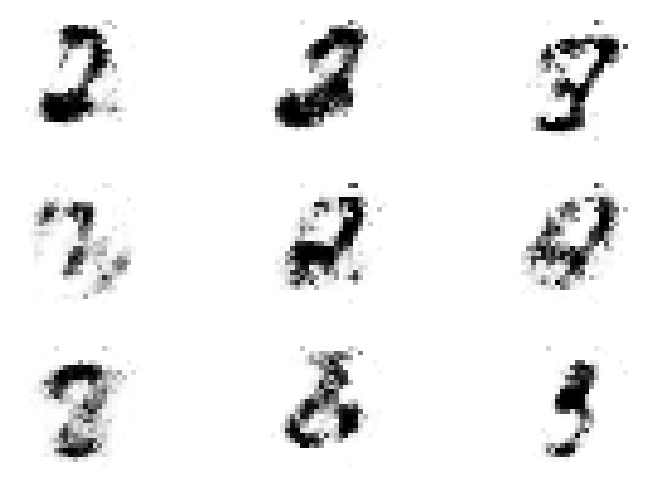

Epoch:170, D-Loss:0.362, D-Acc:91.667, G-Loss:3.832, Sigma:0.0988
Epoch:171, D-Loss:0.236, D-Acc:96.667, G-Loss:3.683, Sigma:0.0987
Epoch:172, D-Loss:0.181, D-Acc:93.333, G-Loss:4.096, Sigma:0.0987
Epoch:173, D-Loss:0.158, D-Acc:98.333, G-Loss:4.018, Sigma:0.0987
Epoch:174, D-Loss:0.226, D-Acc:93.333, G-Loss:4.084, Sigma:0.0987


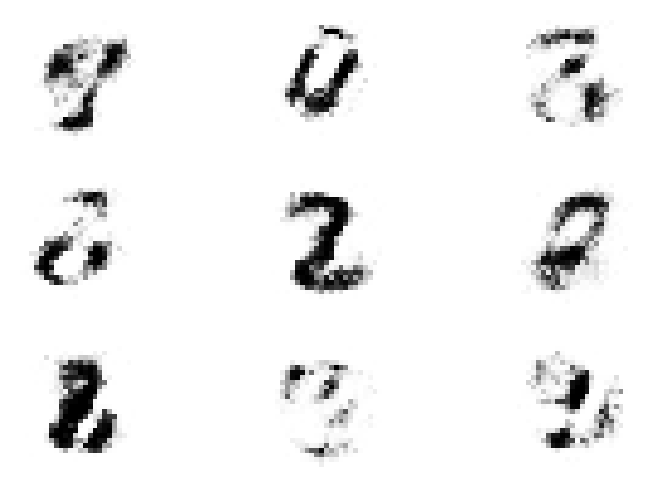

Epoch:175, D-Loss:0.242, D-Acc:96.667, G-Loss:3.568, Sigma:0.0987
Epoch:176, D-Loss:0.192, D-Acc:96.667, G-Loss:4.056, Sigma:0.0987
Epoch:177, D-Loss:0.135, D-Acc:96.667, G-Loss:3.573, Sigma:0.0987
Epoch:178, D-Loss:0.333, D-Acc:90.000, G-Loss:3.781, Sigma:0.0987
Epoch:179, D-Loss:0.482, D-Acc:95.000, G-Loss:3.850, Sigma:0.0987


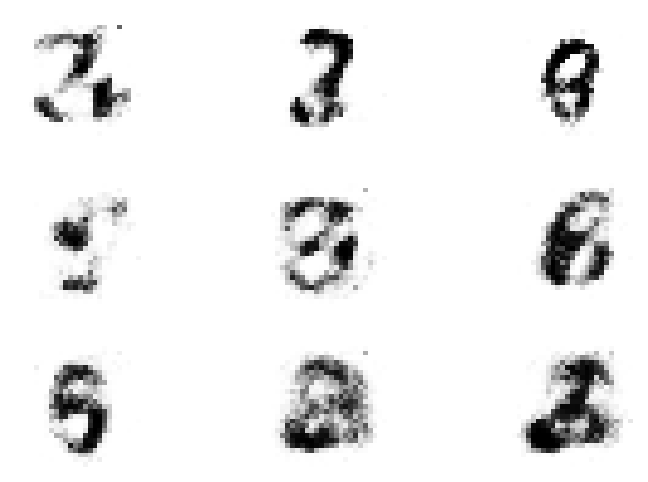

Epoch:180, D-Loss:0.237, D-Acc:96.667, G-Loss:3.521, Sigma:0.0987
Epoch:181, D-Loss:0.454, D-Acc:88.333, G-Loss:2.963, Sigma:0.0987
Epoch:182, D-Loss:0.243, D-Acc:95.000, G-Loss:3.862, Sigma:0.0987
Epoch:183, D-Loss:0.252, D-Acc:96.667, G-Loss:4.025, Sigma:0.0987
Epoch:184, D-Loss:0.202, D-Acc:96.667, G-Loss:3.527, Sigma:0.0987


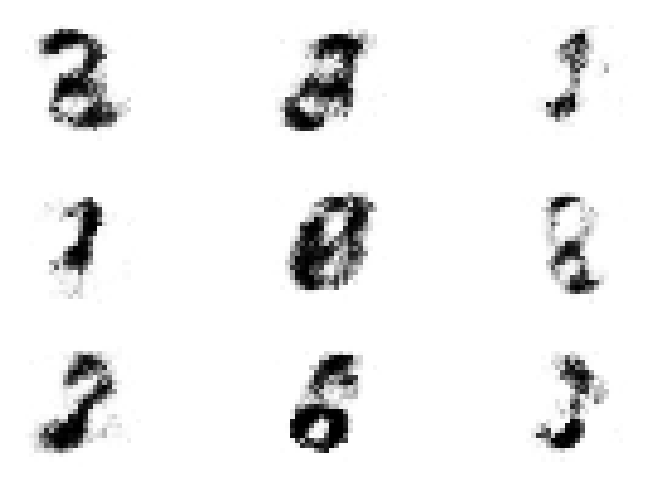

Epoch:185, D-Loss:0.374, D-Acc:90.000, G-Loss:2.974, Sigma:0.0987
Epoch:186, D-Loss:0.336, D-Acc:95.000, G-Loss:3.271, Sigma:0.0987
Epoch:187, D-Loss:0.385, D-Acc:90.000, G-Loss:3.952, Sigma:0.0987
Epoch:188, D-Loss:0.258, D-Acc:95.000, G-Loss:3.889, Sigma:0.0987
Epoch:189, D-Loss:0.163, D-Acc:98.333, G-Loss:3.694, Sigma:0.0987


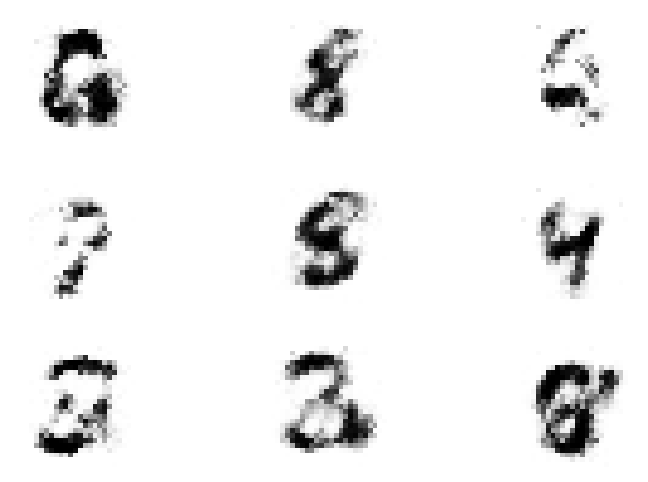

Epoch:190, D-Loss:0.628, D-Acc:81.667, G-Loss:3.444, Sigma:0.0986
Epoch:191, D-Loss:0.284, D-Acc:93.333, G-Loss:4.160, Sigma:0.0986
Epoch:192, D-Loss:0.209, D-Acc:98.333, G-Loss:3.913, Sigma:0.0986
Epoch:193, D-Loss:0.240, D-Acc:96.667, G-Loss:3.920, Sigma:0.0986
Epoch:194, D-Loss:0.183, D-Acc:98.333, G-Loss:3.776, Sigma:0.0986


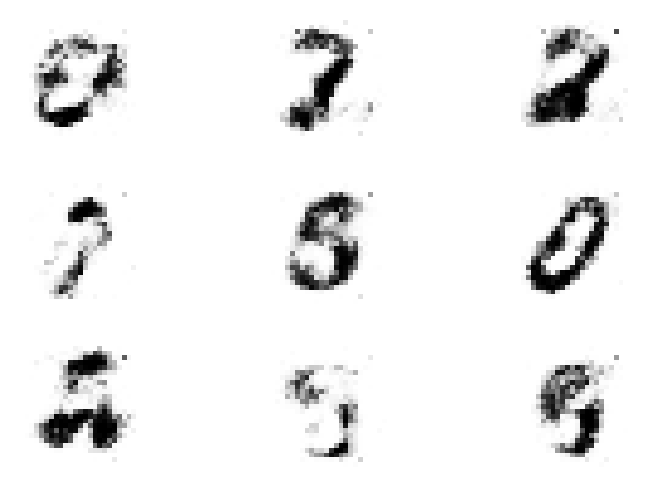

Epoch:195, D-Loss:0.204, D-Acc:96.667, G-Loss:4.215, Sigma:0.0986
Epoch:196, D-Loss:0.246, D-Acc:96.667, G-Loss:3.932, Sigma:0.0986
Epoch:197, D-Loss:0.321, D-Acc:93.333, G-Loss:3.686, Sigma:0.0986
Epoch:198, D-Loss:0.204, D-Acc:96.667, G-Loss:4.494, Sigma:0.0986
Epoch:199, D-Loss:0.332, D-Acc:88.333, G-Loss:3.161, Sigma:0.0986


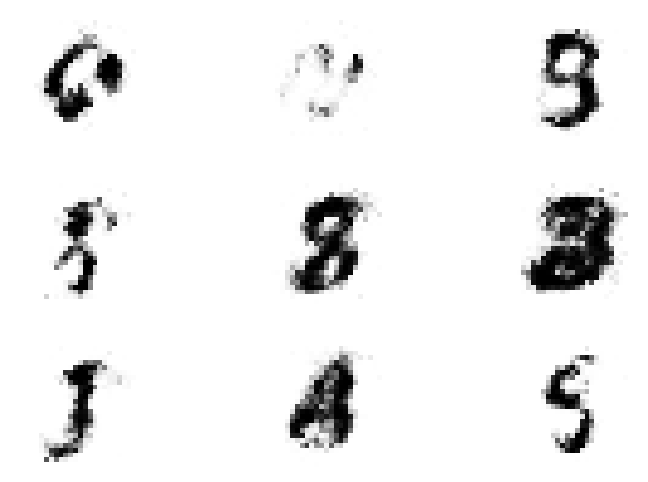

Epoch:200, D-Loss:0.523, D-Acc:88.333, G-Loss:4.125, Sigma:0.0986
Epoch:201, D-Loss:0.484, D-Acc:88.333, G-Loss:4.066, Sigma:0.0986
Epoch:202, D-Loss:0.236, D-Acc:95.000, G-Loss:3.823, Sigma:0.0986
Epoch:203, D-Loss:0.327, D-Acc:93.333, G-Loss:4.219, Sigma:0.0986
Epoch:204, D-Loss:0.220, D-Acc:95.000, G-Loss:3.492, Sigma:0.0986


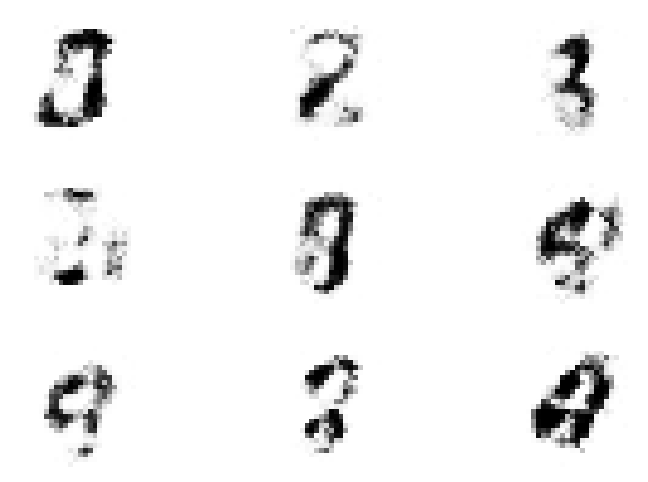

Epoch:205, D-Loss:0.343, D-Acc:90.000, G-Loss:3.729, Sigma:0.0986
Epoch:206, D-Loss:0.374, D-Acc:91.667, G-Loss:3.933, Sigma:0.0986
Epoch:207, D-Loss:0.325, D-Acc:91.667, G-Loss:3.619, Sigma:0.0986
Epoch:208, D-Loss:0.373, D-Acc:90.000, G-Loss:3.284, Sigma:0.0986
Epoch:209, D-Loss:0.346, D-Acc:93.333, G-Loss:3.341, Sigma:0.0986


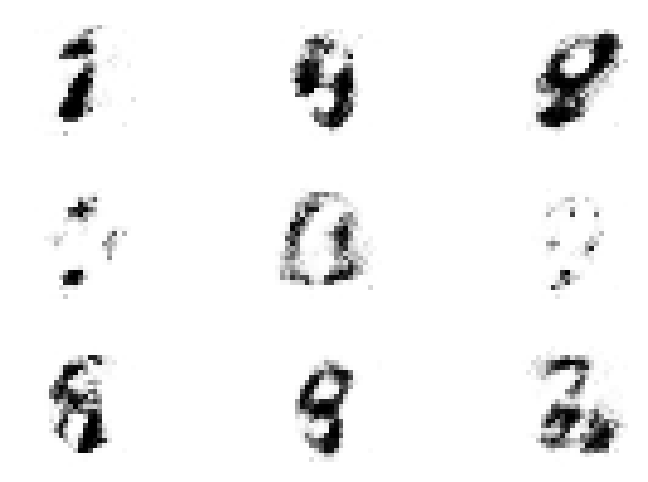

Epoch:210, D-Loss:0.516, D-Acc:85.000, G-Loss:3.407, Sigma:0.0986
Epoch:211, D-Loss:0.174, D-Acc:96.667, G-Loss:3.180, Sigma:0.0986
Epoch:212, D-Loss:0.306, D-Acc:93.333, G-Loss:3.429, Sigma:0.0986
Epoch:213, D-Loss:0.267, D-Acc:91.667, G-Loss:3.359, Sigma:0.0986
Epoch:214, D-Loss:0.398, D-Acc:91.667, G-Loss:4.233, Sigma:0.0986


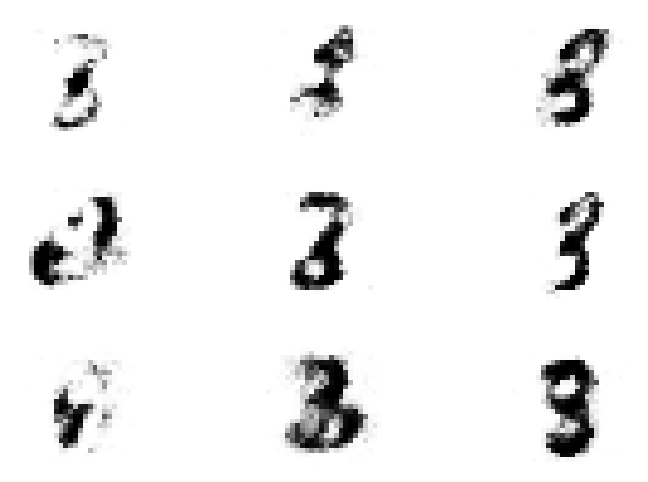

Epoch:215, D-Loss:0.334, D-Acc:95.000, G-Loss:3.481, Sigma:0.0986
Epoch:216, D-Loss:0.192, D-Acc:96.667, G-Loss:4.051, Sigma:0.0986
Epoch:217, D-Loss:0.695, D-Acc:88.333, G-Loss:3.338, Sigma:0.0986
Epoch:218, D-Loss:0.475, D-Acc:91.667, G-Loss:3.955, Sigma:0.0985
Epoch:219, D-Loss:0.288, D-Acc:93.333, G-Loss:3.421, Sigma:0.0985


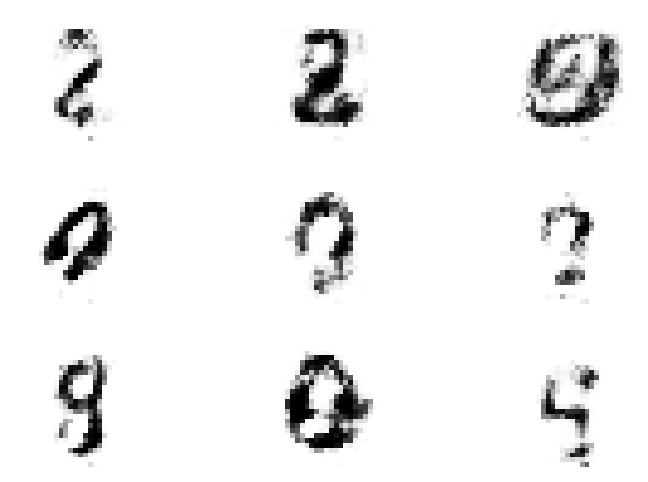

Epoch:220, D-Loss:0.335, D-Acc:91.667, G-Loss:3.396, Sigma:0.0985
Epoch:221, D-Loss:0.329, D-Acc:95.000, G-Loss:3.391, Sigma:0.0985
Epoch:222, D-Loss:0.233, D-Acc:96.667, G-Loss:3.381, Sigma:0.0985
Epoch:223, D-Loss:0.541, D-Acc:88.333, G-Loss:4.053, Sigma:0.0985
Epoch:224, D-Loss:0.611, D-Acc:93.333, G-Loss:3.077, Sigma:0.0985


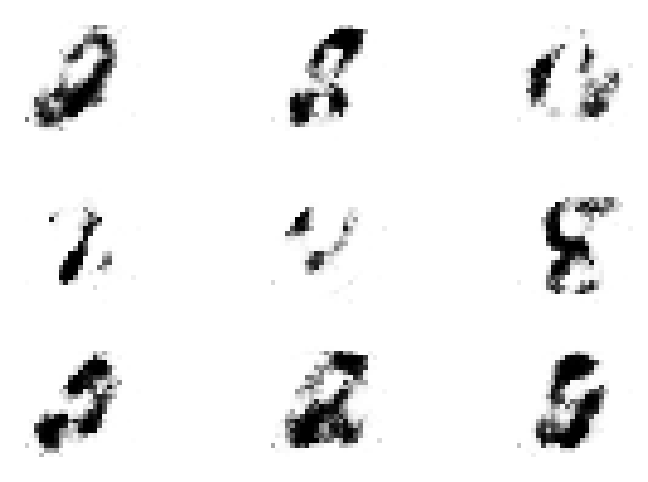

Epoch:225, D-Loss:0.395, D-Acc:90.000, G-Loss:3.451, Sigma:0.0985
Epoch:226, D-Loss:0.256, D-Acc:95.000, G-Loss:3.238, Sigma:0.0985
Epoch:227, D-Loss:0.146, D-Acc:98.333, G-Loss:3.785, Sigma:0.0985
Epoch:228, D-Loss:0.360, D-Acc:91.667, G-Loss:3.055, Sigma:0.0985
Epoch:229, D-Loss:0.361, D-Acc:93.333, G-Loss:3.765, Sigma:0.0985


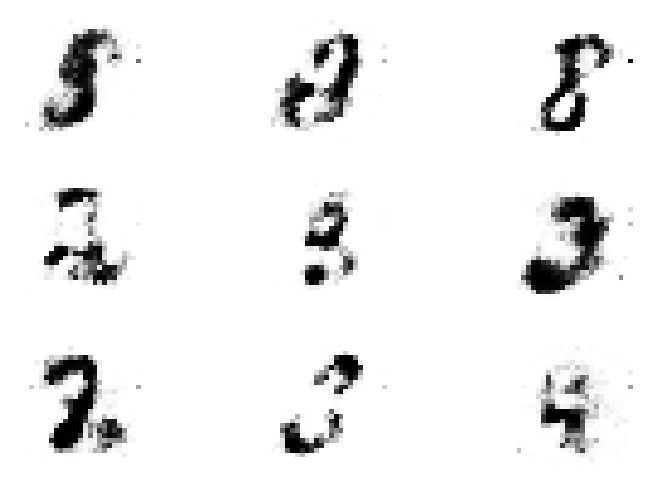

Epoch:230, D-Loss:0.312, D-Acc:93.333, G-Loss:4.234, Sigma:0.0985
Epoch:231, D-Loss:0.321, D-Acc:95.000, G-Loss:3.214, Sigma:0.0985
Epoch:232, D-Loss:0.319, D-Acc:95.000, G-Loss:3.678, Sigma:0.0985
Epoch:233, D-Loss:0.448, D-Acc:91.667, G-Loss:3.112, Sigma:0.0985
Epoch:234, D-Loss:0.335, D-Acc:95.000, G-Loss:3.585, Sigma:0.0985


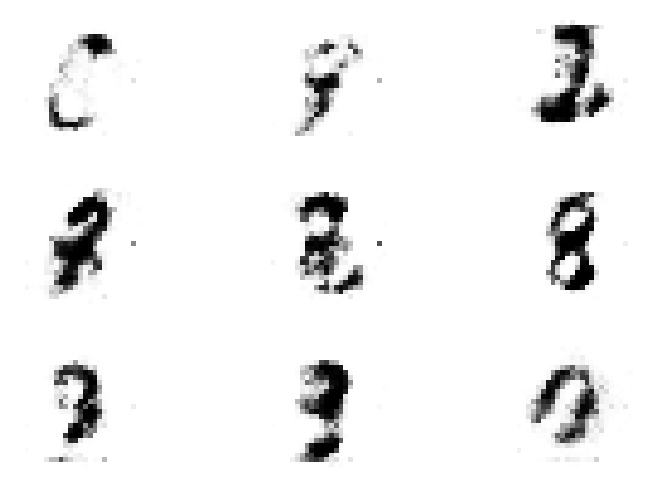

Epoch:235, D-Loss:0.778, D-Acc:86.667, G-Loss:3.420, Sigma:0.0985
Epoch:236, D-Loss:0.413, D-Acc:93.333, G-Loss:3.035, Sigma:0.0985
Epoch:237, D-Loss:0.199, D-Acc:96.667, G-Loss:3.492, Sigma:0.0985
Epoch:238, D-Loss:0.540, D-Acc:90.000, G-Loss:3.454, Sigma:0.0985
Epoch:239, D-Loss:0.260, D-Acc:93.333, G-Loss:3.488, Sigma:0.0985


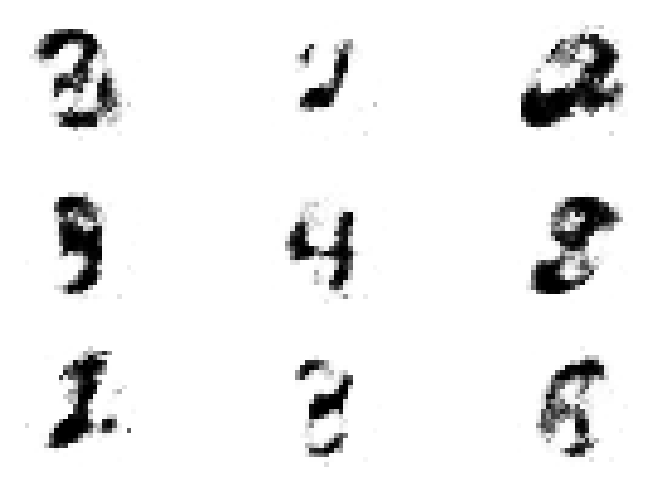

Epoch:240, D-Loss:0.508, D-Acc:91.667, G-Loss:3.950, Sigma:0.0985
Epoch:241, D-Loss:0.314, D-Acc:93.333, G-Loss:2.998, Sigma:0.0985
Epoch:242, D-Loss:0.207, D-Acc:96.667, G-Loss:3.018, Sigma:0.0985
Epoch:243, D-Loss:0.323, D-Acc:95.000, G-Loss:3.020, Sigma:0.0985
Epoch:244, D-Loss:0.306, D-Acc:95.000, G-Loss:3.778, Sigma:0.0985


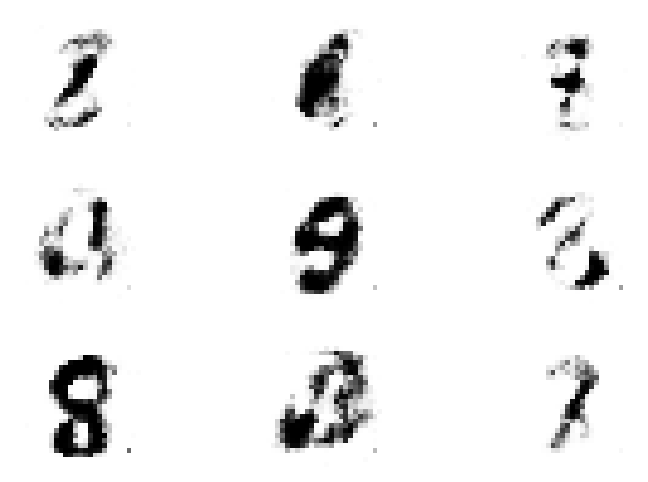

Epoch:245, D-Loss:0.189, D-Acc:98.333, G-Loss:3.507, Sigma:0.0985
Epoch:246, D-Loss:0.433, D-Acc:93.333, G-Loss:3.400, Sigma:0.0985
Epoch:247, D-Loss:0.494, D-Acc:90.000, G-Loss:3.680, Sigma:0.0985
Epoch:248, D-Loss:0.594, D-Acc:88.333, G-Loss:2.839, Sigma:0.0985
Epoch:249, D-Loss:0.604, D-Acc:86.667, G-Loss:3.451, Sigma:0.0985


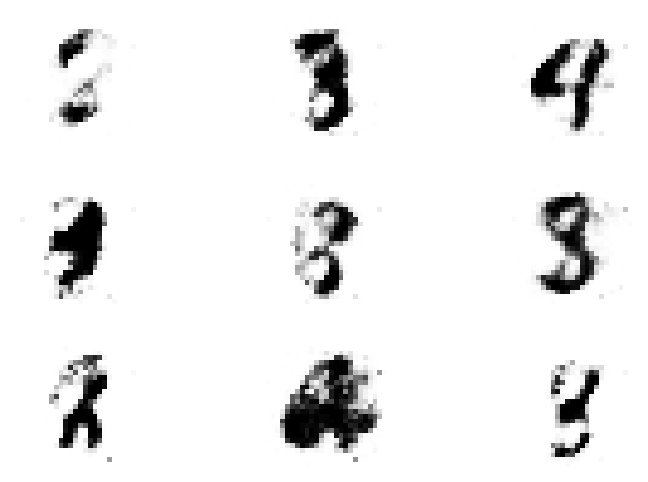

Epoch:250, D-Loss:0.673, D-Acc:86.667, G-Loss:3.024, Sigma:0.0985
Epoch:251, D-Loss:0.418, D-Acc:91.667, G-Loss:3.210, Sigma:0.0985
Epoch:252, D-Loss:0.582, D-Acc:83.333, G-Loss:2.955, Sigma:0.0985
Epoch:253, D-Loss:0.428, D-Acc:86.667, G-Loss:3.531, Sigma:0.0985
Epoch:254, D-Loss:0.456, D-Acc:91.667, G-Loss:3.838, Sigma:0.0985


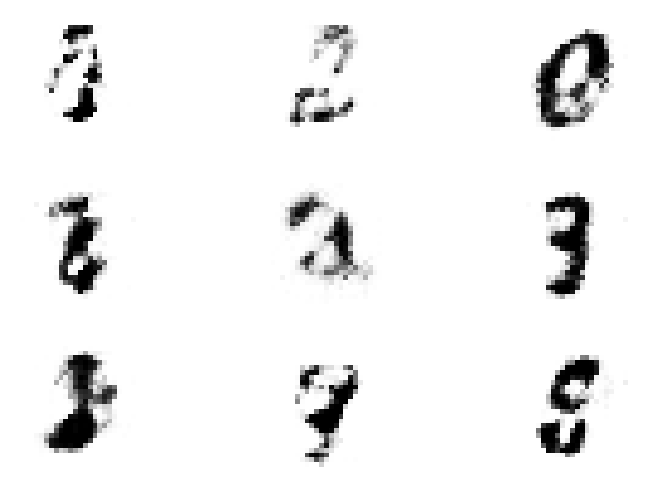

Epoch:255, D-Loss:0.221, D-Acc:98.333, G-Loss:2.949, Sigma:0.0985
Epoch:256, D-Loss:0.534, D-Acc:86.667, G-Loss:3.487, Sigma:0.0985
Epoch:257, D-Loss:0.498, D-Acc:86.667, G-Loss:3.220, Sigma:0.0985
Epoch:258, D-Loss:0.395, D-Acc:91.667, G-Loss:3.334, Sigma:0.0985
Epoch:259, D-Loss:0.358, D-Acc:91.667, G-Loss:2.817, Sigma:0.0985


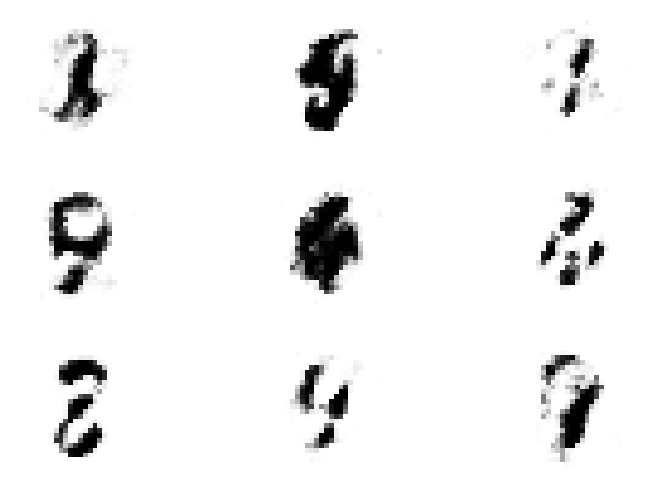

Epoch:260, D-Loss:0.324, D-Acc:91.667, G-Loss:3.135, Sigma:0.0985
Epoch:261, D-Loss:0.427, D-Acc:88.333, G-Loss:3.264, Sigma:0.0985
Epoch:262, D-Loss:0.342, D-Acc:91.667, G-Loss:3.299, Sigma:0.0985
Epoch:263, D-Loss:0.425, D-Acc:88.333, G-Loss:3.350, Sigma:0.0985
Epoch:264, D-Loss:0.508, D-Acc:86.667, G-Loss:3.950, Sigma:0.0985


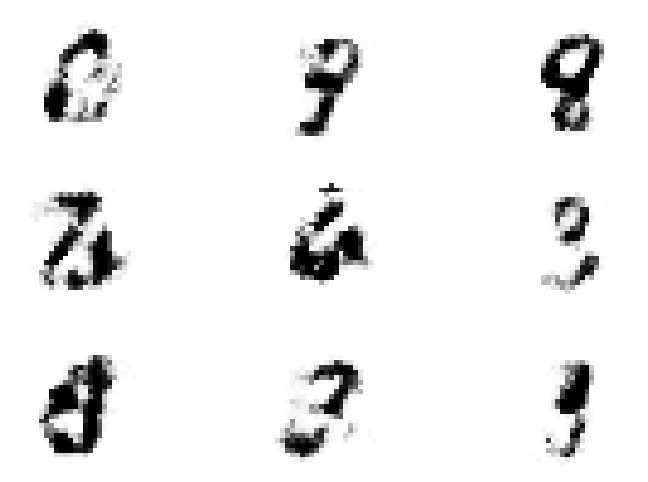

Epoch:265, D-Loss:0.666, D-Acc:91.667, G-Loss:3.388, Sigma:0.0985
Epoch:266, D-Loss:0.661, D-Acc:85.000, G-Loss:2.742, Sigma:0.0985
Epoch:267, D-Loss:0.345, D-Acc:91.667, G-Loss:2.862, Sigma:0.0985
Epoch:268, D-Loss:0.239, D-Acc:95.000, G-Loss:3.072, Sigma:0.0985
Epoch:269, D-Loss:0.585, D-Acc:90.000, G-Loss:3.662, Sigma:0.0985


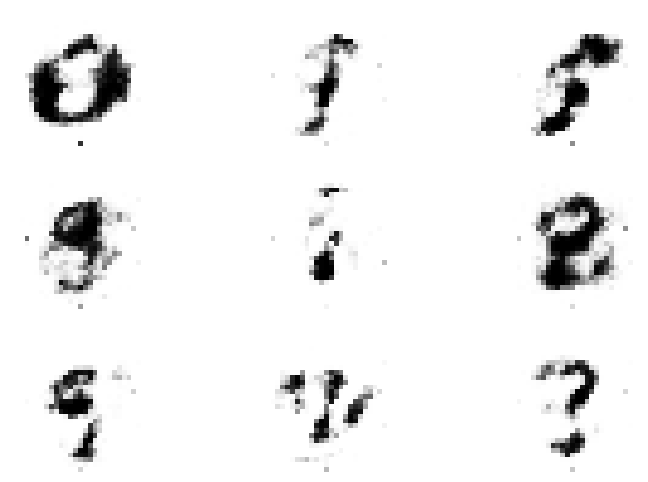

Epoch:270, D-Loss:0.609, D-Acc:88.333, G-Loss:3.334, Sigma:0.0985
Epoch:271, D-Loss:0.348, D-Acc:90.000, G-Loss:3.425, Sigma:0.0985
Epoch:272, D-Loss:0.283, D-Acc:95.000, G-Loss:3.842, Sigma:0.0985
Epoch:273, D-Loss:0.390, D-Acc:91.667, G-Loss:3.170, Sigma:0.0985
Epoch:274, D-Loss:0.462, D-Acc:90.000, G-Loss:2.916, Sigma:0.0985


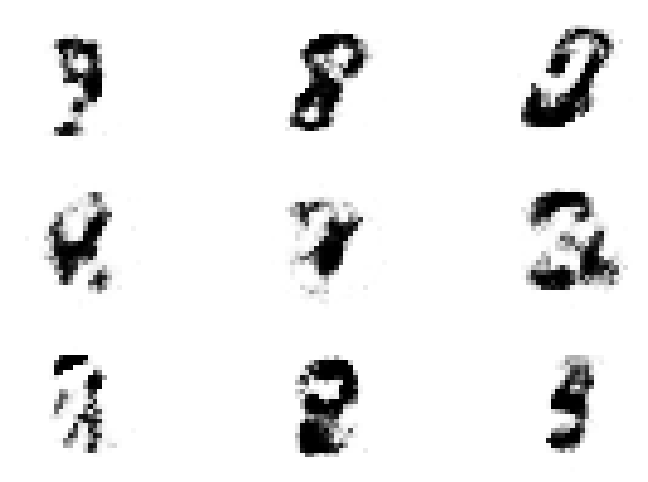

Epoch:275, D-Loss:0.509, D-Acc:86.667, G-Loss:3.293, Sigma:0.0985
Epoch:276, D-Loss:0.406, D-Acc:93.333, G-Loss:2.567, Sigma:0.0985
Epoch:277, D-Loss:0.644, D-Acc:91.667, G-Loss:3.143, Sigma:0.0985
Epoch:278, D-Loss:0.797, D-Acc:80.000, G-Loss:3.141, Sigma:0.0985
Epoch:279, D-Loss:0.488, D-Acc:88.333, G-Loss:3.249, Sigma:0.0985


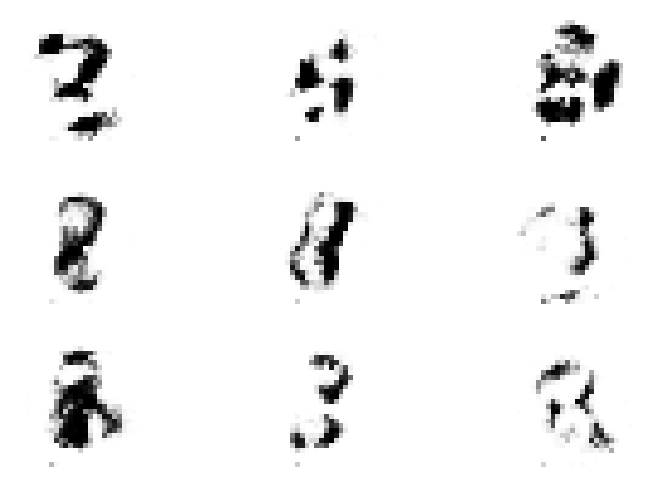

Epoch:280, D-Loss:0.390, D-Acc:95.000, G-Loss:3.058, Sigma:0.0985
Epoch:281, D-Loss:0.478, D-Acc:90.000, G-Loss:2.901, Sigma:0.0985
Epoch:282, D-Loss:0.453, D-Acc:90.000, G-Loss:3.499, Sigma:0.0985
Epoch:283, D-Loss:0.382, D-Acc:88.333, G-Loss:2.505, Sigma:0.0985
Epoch:284, D-Loss:0.658, D-Acc:88.333, G-Loss:2.777, Sigma:0.0985


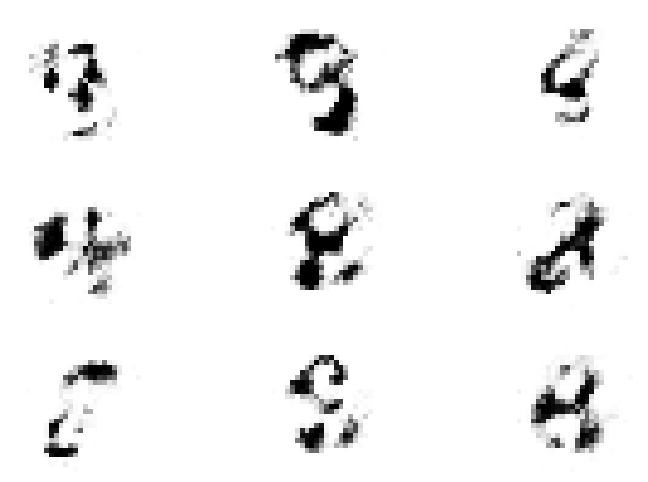

Epoch:285, D-Loss:0.417, D-Acc:93.333, G-Loss:3.190, Sigma:0.0985
Epoch:286, D-Loss:0.427, D-Acc:90.000, G-Loss:3.248, Sigma:0.0985
Epoch:287, D-Loss:0.244, D-Acc:98.333, G-Loss:3.453, Sigma:0.0985
Epoch:288, D-Loss:0.309, D-Acc:93.333, G-Loss:2.821, Sigma:0.0985
Epoch:289, D-Loss:0.663, D-Acc:86.667, G-Loss:3.151, Sigma:0.0985


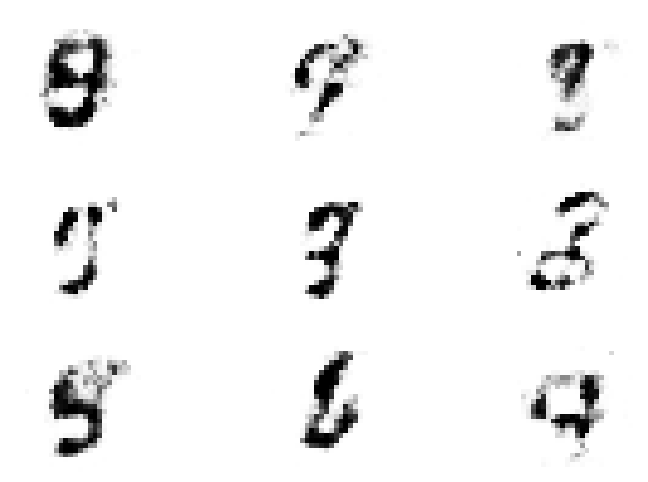

Epoch:290, D-Loss:0.716, D-Acc:85.000, G-Loss:3.179, Sigma:0.0985
Epoch:291, D-Loss:0.444, D-Acc:91.667, G-Loss:2.986, Sigma:0.0985
Epoch:292, D-Loss:0.460, D-Acc:91.667, G-Loss:3.261, Sigma:0.0985
Epoch:293, D-Loss:0.524, D-Acc:88.333, G-Loss:2.938, Sigma:0.0985
Epoch:294, D-Loss:0.749, D-Acc:83.333, G-Loss:2.857, Sigma:0.0985


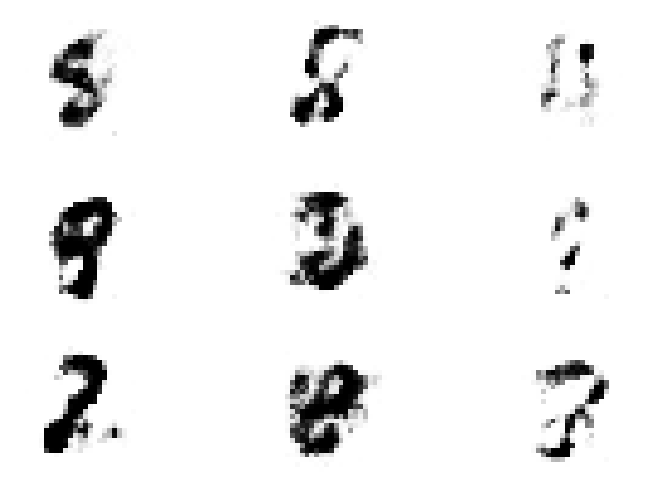

Epoch:295, D-Loss:0.408, D-Acc:91.667, G-Loss:3.065, Sigma:0.0985
Epoch:296, D-Loss:0.559, D-Acc:90.000, G-Loss:3.147, Sigma:0.0985
Epoch:297, D-Loss:0.414, D-Acc:90.000, G-Loss:3.121, Sigma:0.0985
Epoch:298, D-Loss:0.417, D-Acc:93.333, G-Loss:3.767, Sigma:0.0985
Epoch:299, D-Loss:0.380, D-Acc:93.333, G-Loss:2.603, Sigma:0.0985


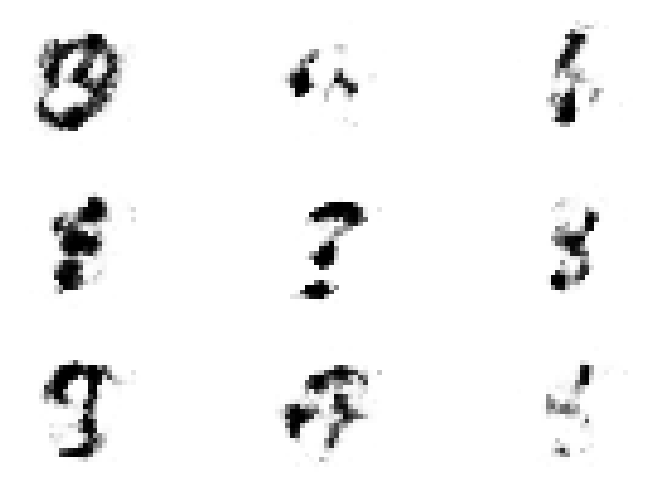

Epoch:300, D-Loss:0.291, D-Acc:96.667, G-Loss:3.011, Sigma:0.0985
Epoch:301, D-Loss:0.639, D-Acc:83.333, G-Loss:2.898, Sigma:0.0985
Epoch:302, D-Loss:0.438, D-Acc:91.667, G-Loss:2.739, Sigma:0.0985
Epoch:303, D-Loss:0.718, D-Acc:85.000, G-Loss:3.247, Sigma:0.0985
Epoch:304, D-Loss:0.680, D-Acc:88.333, G-Loss:3.121, Sigma:0.0985


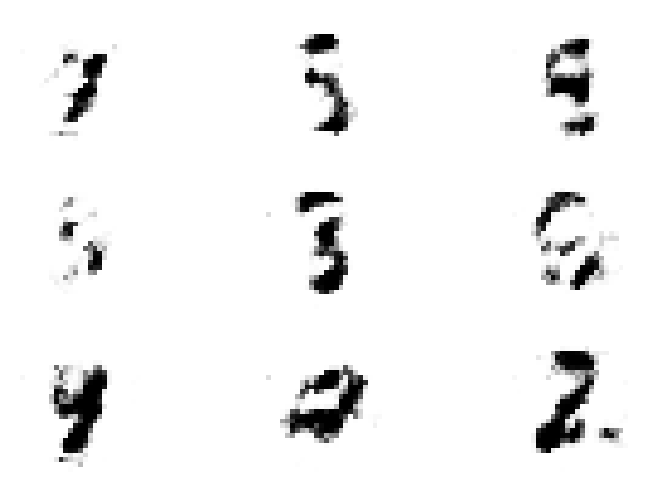

Epoch:305, D-Loss:0.584, D-Acc:91.667, G-Loss:2.742, Sigma:0.0985
Epoch:306, D-Loss:0.224, D-Acc:95.000, G-Loss:3.005, Sigma:0.0985
Epoch:307, D-Loss:0.450, D-Acc:91.667, G-Loss:3.128, Sigma:0.0985
Epoch:308, D-Loss:0.408, D-Acc:90.000, G-Loss:2.678, Sigma:0.0985
Epoch:309, D-Loss:0.508, D-Acc:91.667, G-Loss:2.631, Sigma:0.0985


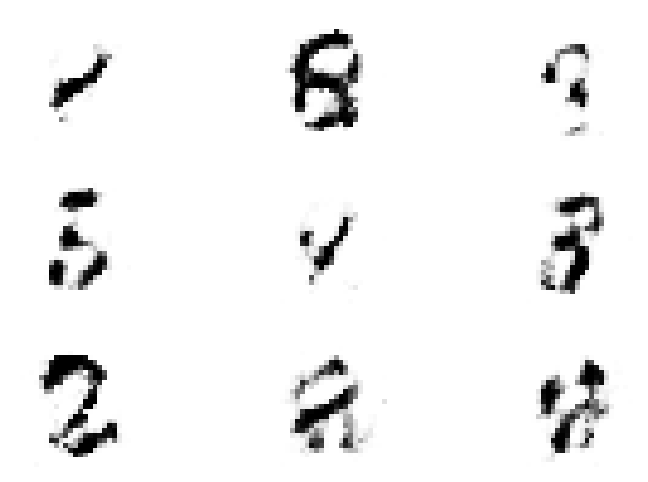

Epoch:310, D-Loss:0.653, D-Acc:90.000, G-Loss:3.197, Sigma:0.0985
Epoch:311, D-Loss:0.381, D-Acc:95.000, G-Loss:2.935, Sigma:0.0985
Epoch:312, D-Loss:0.473, D-Acc:85.000, G-Loss:2.657, Sigma:0.0984
Epoch:313, D-Loss:0.428, D-Acc:90.000, G-Loss:2.740, Sigma:0.0984
Epoch:314, D-Loss:0.426, D-Acc:93.333, G-Loss:3.264, Sigma:0.0984


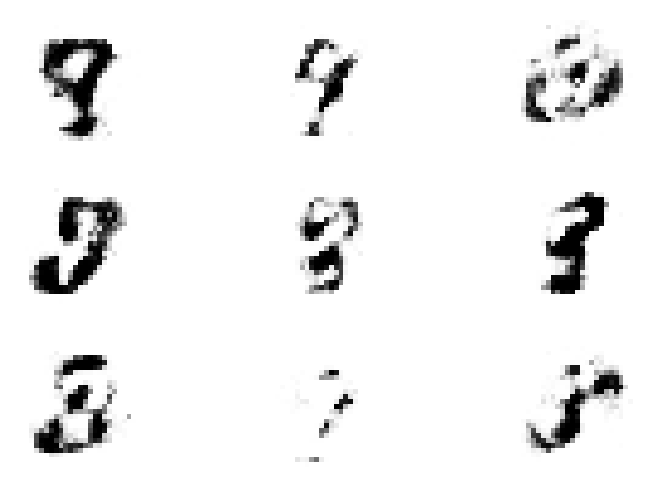

Epoch:315, D-Loss:0.357, D-Acc:93.333, G-Loss:3.274, Sigma:0.0984
Epoch:316, D-Loss:0.466, D-Acc:91.667, G-Loss:2.950, Sigma:0.0984
Epoch:317, D-Loss:0.430, D-Acc:95.000, G-Loss:2.537, Sigma:0.0984
Epoch:318, D-Loss:0.504, D-Acc:95.000, G-Loss:3.185, Sigma:0.0984
Epoch:319, D-Loss:0.445, D-Acc:93.333, G-Loss:3.129, Sigma:0.0984


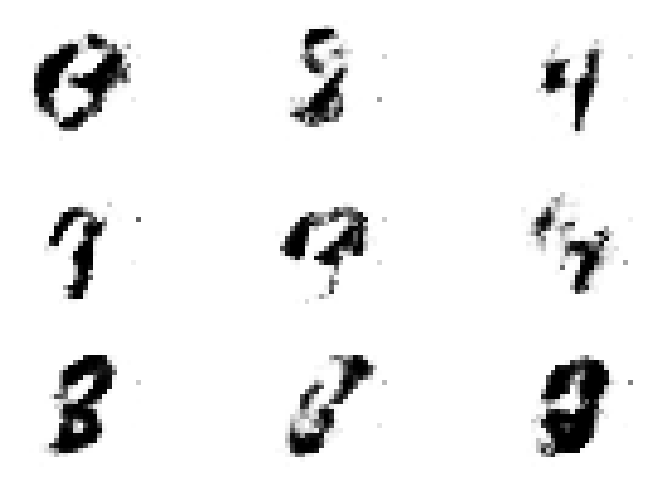

Epoch:320, D-Loss:0.315, D-Acc:90.000, G-Loss:2.852, Sigma:0.0984
Epoch:321, D-Loss:0.711, D-Acc:86.667, G-Loss:3.275, Sigma:0.0984
Epoch:322, D-Loss:0.677, D-Acc:86.667, G-Loss:2.828, Sigma:0.0984
Epoch:323, D-Loss:0.485, D-Acc:90.000, G-Loss:3.098, Sigma:0.0984
Epoch:324, D-Loss:0.459, D-Acc:90.000, G-Loss:2.548, Sigma:0.0984


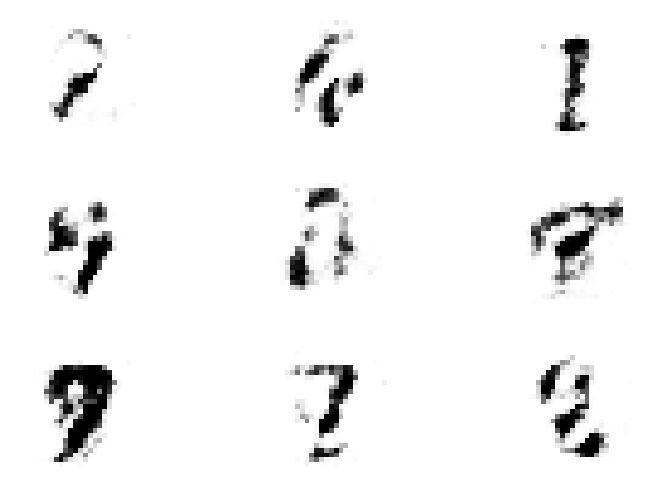

Epoch:325, D-Loss:0.451, D-Acc:88.333, G-Loss:3.110, Sigma:0.0984
Epoch:326, D-Loss:0.600, D-Acc:88.333, G-Loss:3.000, Sigma:0.0984
Epoch:327, D-Loss:0.446, D-Acc:90.000, G-Loss:2.513, Sigma:0.0984
Epoch:328, D-Loss:0.369, D-Acc:95.000, G-Loss:2.963, Sigma:0.0984
Epoch:329, D-Loss:0.226, D-Acc:96.667, G-Loss:2.753, Sigma:0.0984


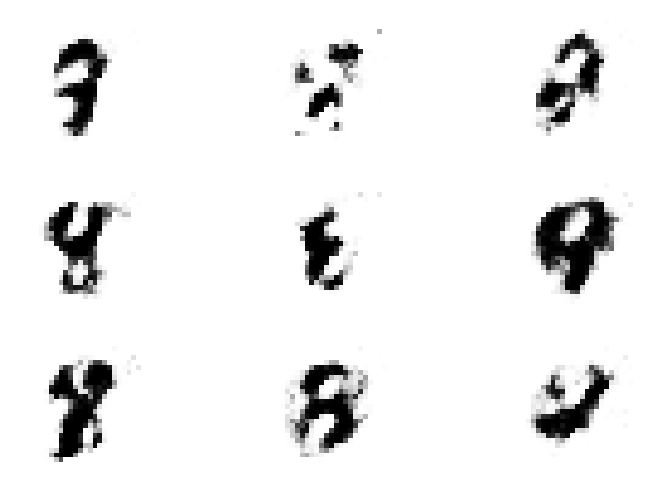

Epoch:330, D-Loss:0.775, D-Acc:83.333, G-Loss:2.636, Sigma:0.0984
Epoch:331, D-Loss:0.519, D-Acc:93.333, G-Loss:2.696, Sigma:0.0984
Epoch:332, D-Loss:0.596, D-Acc:93.333, G-Loss:2.866, Sigma:0.0984
Epoch:333, D-Loss:0.468, D-Acc:88.333, G-Loss:2.972, Sigma:0.0984
Epoch:334, D-Loss:0.480, D-Acc:90.000, G-Loss:2.589, Sigma:0.0984


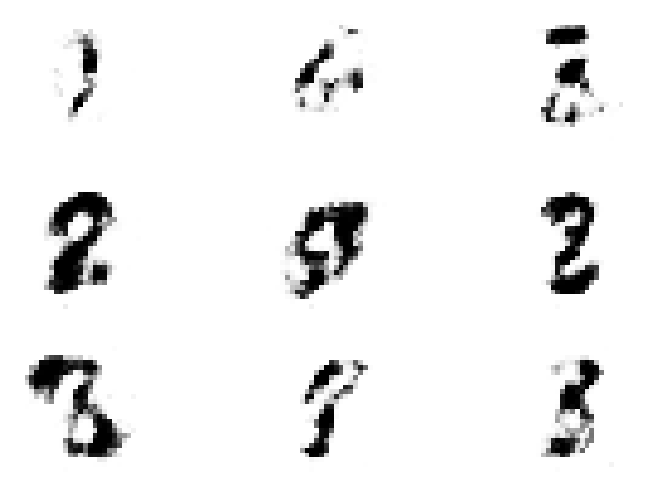

Epoch:335, D-Loss:0.526, D-Acc:91.667, G-Loss:2.816, Sigma:0.0984
Epoch:336, D-Loss:0.533, D-Acc:90.000, G-Loss:2.967, Sigma:0.0984
Epoch:337, D-Loss:0.563, D-Acc:81.667, G-Loss:3.357, Sigma:0.0984
Epoch:338, D-Loss:0.630, D-Acc:86.667, G-Loss:3.484, Sigma:0.0984
Epoch:339, D-Loss:0.340, D-Acc:95.000, G-Loss:2.450, Sigma:0.0984


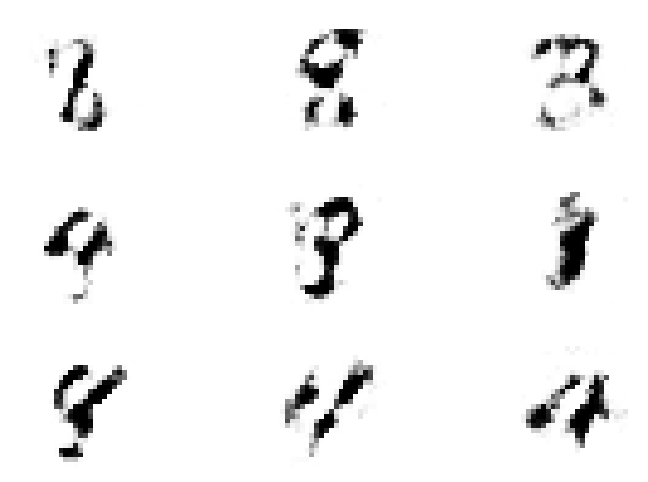

Epoch:340, D-Loss:0.749, D-Acc:85.000, G-Loss:3.439, Sigma:0.0984
Epoch:341, D-Loss:0.479, D-Acc:91.667, G-Loss:2.537, Sigma:0.0984
Epoch:342, D-Loss:0.444, D-Acc:88.333, G-Loss:3.302, Sigma:0.0984
Epoch:343, D-Loss:0.587, D-Acc:90.000, G-Loss:2.947, Sigma:0.0984
Epoch:344, D-Loss:0.282, D-Acc:95.000, G-Loss:3.295, Sigma:0.0984


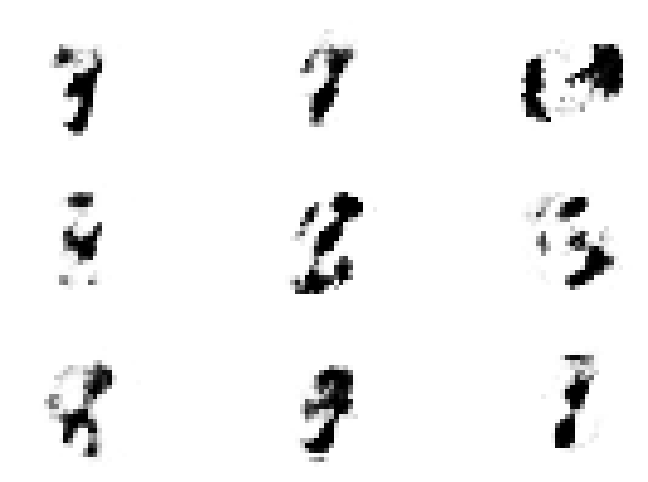

Epoch:345, D-Loss:0.488, D-Acc:90.000, G-Loss:2.923, Sigma:0.0984
Epoch:346, D-Loss:0.466, D-Acc:90.000, G-Loss:2.646, Sigma:0.0984
Epoch:347, D-Loss:0.473, D-Acc:90.000, G-Loss:2.980, Sigma:0.0984
Epoch:348, D-Loss:0.188, D-Acc:95.000, G-Loss:3.045, Sigma:0.0984
Epoch:349, D-Loss:0.757, D-Acc:88.333, G-Loss:2.963, Sigma:0.0984


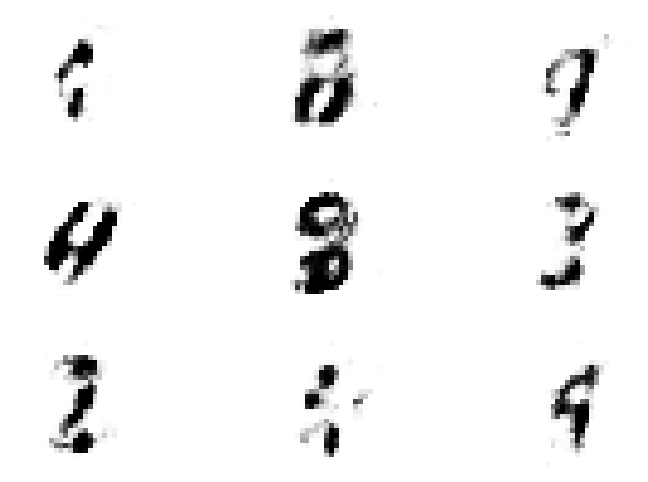

Epoch:350, D-Loss:0.379, D-Acc:90.000, G-Loss:2.856, Sigma:0.0984
Epoch:351, D-Loss:0.545, D-Acc:88.333, G-Loss:2.870, Sigma:0.0984
Epoch:352, D-Loss:0.538, D-Acc:88.333, G-Loss:3.270, Sigma:0.0984
Epoch:353, D-Loss:0.443, D-Acc:90.000, G-Loss:2.623, Sigma:0.0984
Epoch:354, D-Loss:0.462, D-Acc:90.000, G-Loss:2.478, Sigma:0.0984


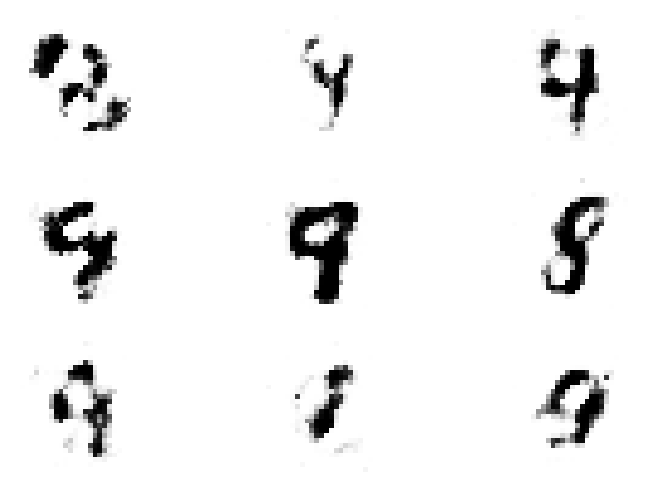

Epoch:355, D-Loss:0.245, D-Acc:96.667, G-Loss:3.146, Sigma:0.0984
Epoch:356, D-Loss:0.416, D-Acc:91.667, G-Loss:2.773, Sigma:0.0984
Epoch:357, D-Loss:0.393, D-Acc:90.000, G-Loss:3.231, Sigma:0.0984
Epoch:358, D-Loss:0.687, D-Acc:85.000, G-Loss:3.649, Sigma:0.0984
Epoch:359, D-Loss:0.440, D-Acc:90.000, G-Loss:3.024, Sigma:0.0984


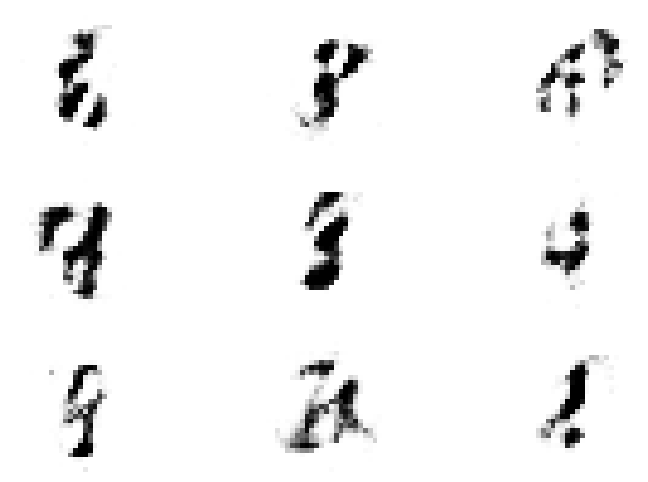

Epoch:360, D-Loss:0.721, D-Acc:86.667, G-Loss:2.922, Sigma:0.0984
Epoch:361, D-Loss:0.487, D-Acc:88.333, G-Loss:3.178, Sigma:0.0984
Epoch:362, D-Loss:0.476, D-Acc:91.667, G-Loss:2.820, Sigma:0.0984
Epoch:363, D-Loss:0.494, D-Acc:86.667, G-Loss:2.423, Sigma:0.0984
Epoch:364, D-Loss:0.601, D-Acc:86.667, G-Loss:2.725, Sigma:0.0984


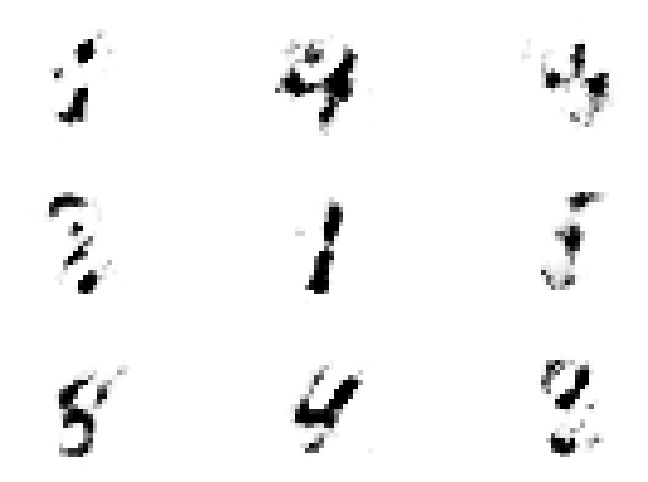

Epoch:365, D-Loss:0.613, D-Acc:90.000, G-Loss:2.687, Sigma:0.0984
Epoch:366, D-Loss:0.681, D-Acc:88.333, G-Loss:3.049, Sigma:0.0984
Epoch:367, D-Loss:0.267, D-Acc:95.000, G-Loss:2.783, Sigma:0.0984
Epoch:368, D-Loss:0.583, D-Acc:88.333, G-Loss:3.131, Sigma:0.0984
Epoch:369, D-Loss:0.503, D-Acc:90.000, G-Loss:3.682, Sigma:0.0984


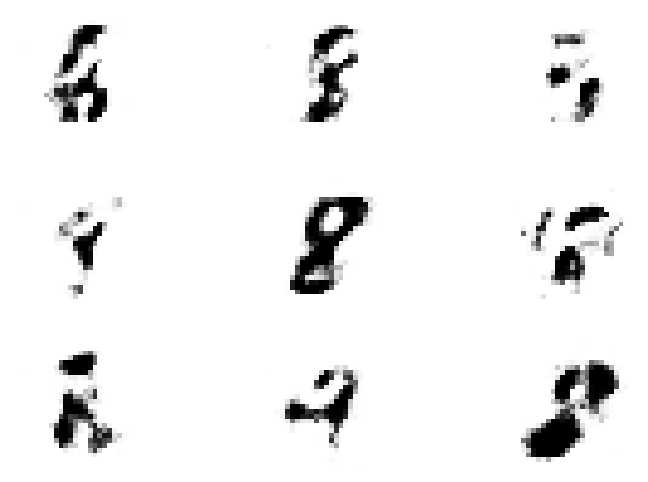

Epoch:370, D-Loss:0.369, D-Acc:91.667, G-Loss:3.010, Sigma:0.0984
Epoch:371, D-Loss:0.573, D-Acc:90.000, G-Loss:2.859, Sigma:0.0984
Epoch:372, D-Loss:0.339, D-Acc:95.000, G-Loss:3.235, Sigma:0.0984
Epoch:373, D-Loss:0.231, D-Acc:98.333, G-Loss:2.601, Sigma:0.0983
Epoch:374, D-Loss:0.459, D-Acc:90.000, G-Loss:2.961, Sigma:0.0983


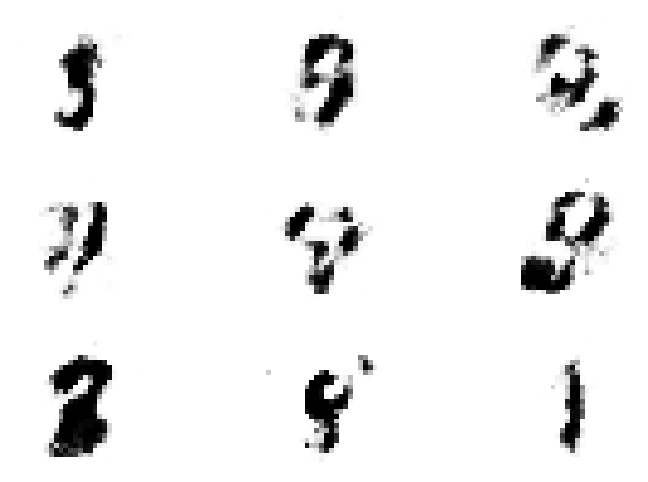

Epoch:375, D-Loss:0.573, D-Acc:86.667, G-Loss:2.957, Sigma:0.0983
Epoch:376, D-Loss:0.592, D-Acc:83.333, G-Loss:3.172, Sigma:0.0983
Epoch:377, D-Loss:0.565, D-Acc:85.000, G-Loss:2.953, Sigma:0.0983
Epoch:378, D-Loss:0.312, D-Acc:95.000, G-Loss:3.163, Sigma:0.0983
Epoch:379, D-Loss:0.429, D-Acc:91.667, G-Loss:2.704, Sigma:0.0983


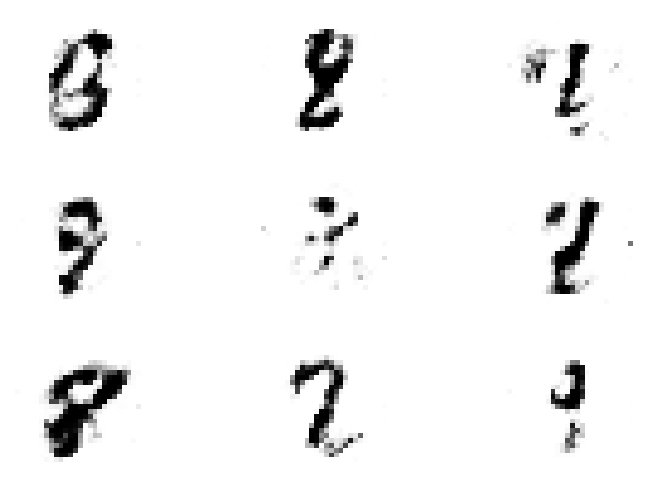

Epoch:380, D-Loss:0.234, D-Acc:98.333, G-Loss:3.296, Sigma:0.0983
Epoch:381, D-Loss:0.614, D-Acc:81.667, G-Loss:2.577, Sigma:0.0983
Epoch:382, D-Loss:0.323, D-Acc:91.667, G-Loss:3.124, Sigma:0.0983
Epoch:383, D-Loss:0.595, D-Acc:91.667, G-Loss:3.799, Sigma:0.0983
Epoch:384, D-Loss:0.327, D-Acc:93.333, G-Loss:2.764, Sigma:0.0983


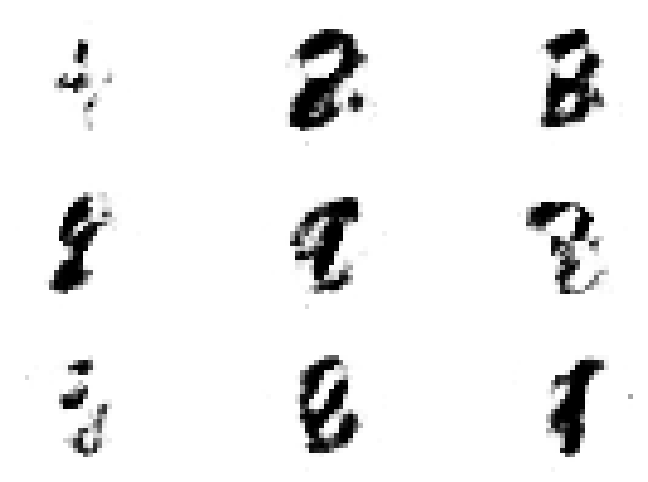

Epoch:385, D-Loss:0.652, D-Acc:85.000, G-Loss:2.434, Sigma:0.0983
Epoch:386, D-Loss:0.408, D-Acc:90.000, G-Loss:3.154, Sigma:0.0983
Epoch:387, D-Loss:0.369, D-Acc:93.333, G-Loss:3.043, Sigma:0.0983
Epoch:388, D-Loss:0.534, D-Acc:88.333, G-Loss:2.814, Sigma:0.0983
Epoch:389, D-Loss:0.343, D-Acc:91.667, G-Loss:3.219, Sigma:0.0983


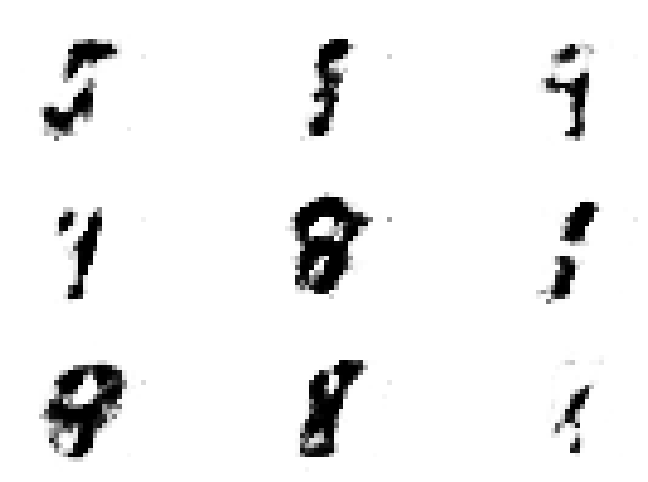

Epoch:390, D-Loss:0.389, D-Acc:91.667, G-Loss:3.233, Sigma:0.0983
Epoch:391, D-Loss:0.439, D-Acc:90.000, G-Loss:3.111, Sigma:0.0983
Epoch:392, D-Loss:0.429, D-Acc:90.000, G-Loss:3.006, Sigma:0.0983
Epoch:393, D-Loss:0.331, D-Acc:93.333, G-Loss:2.759, Sigma:0.0983
Epoch:394, D-Loss:0.446, D-Acc:88.333, G-Loss:2.787, Sigma:0.0983


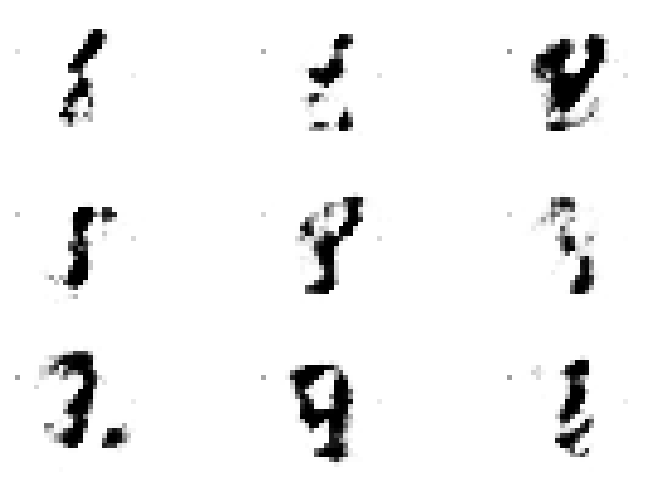

Epoch:395, D-Loss:0.320, D-Acc:93.333, G-Loss:2.705, Sigma:0.0983
Epoch:396, D-Loss:0.454, D-Acc:93.333, G-Loss:2.868, Sigma:0.0983
Epoch:397, D-Loss:0.317, D-Acc:100.000, G-Loss:2.612, Sigma:0.0983
Epoch:398, D-Loss:0.321, D-Acc:95.000, G-Loss:3.094, Sigma:0.0983
Epoch:399, D-Loss:0.415, D-Acc:90.000, G-Loss:2.954, Sigma:0.0983


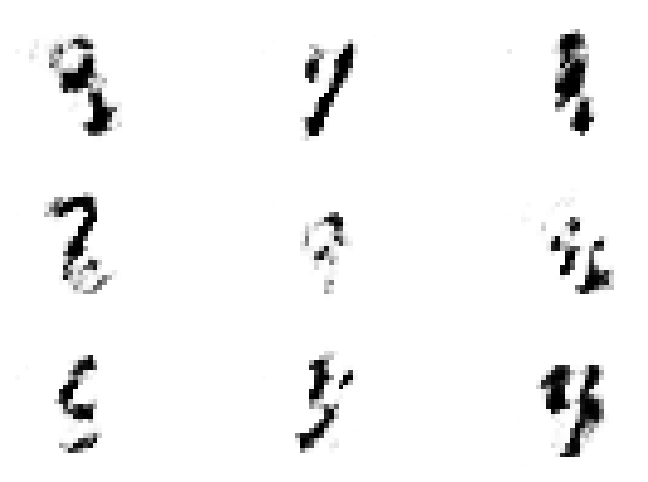

Epoch:400, D-Loss:0.346, D-Acc:93.333, G-Loss:2.698, Sigma:0.0983
Epoch:401, D-Loss:0.512, D-Acc:90.000, G-Loss:2.784, Sigma:0.0983
Epoch:402, D-Loss:0.485, D-Acc:88.333, G-Loss:2.971, Sigma:0.0983
Epoch:403, D-Loss:0.583, D-Acc:88.333, G-Loss:2.416, Sigma:0.0983
Epoch:404, D-Loss:0.328, D-Acc:96.667, G-Loss:2.818, Sigma:0.0983


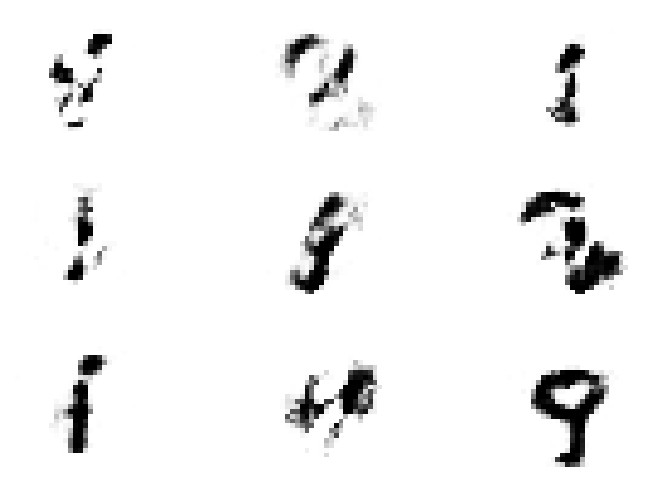

Epoch:405, D-Loss:0.467, D-Acc:90.000, G-Loss:2.761, Sigma:0.0983
Epoch:406, D-Loss:0.253, D-Acc:96.667, G-Loss:3.035, Sigma:0.0983
Epoch:407, D-Loss:0.448, D-Acc:86.667, G-Loss:3.141, Sigma:0.0983
Epoch:408, D-Loss:0.748, D-Acc:86.667, G-Loss:2.961, Sigma:0.0983
Epoch:409, D-Loss:0.370, D-Acc:93.333, G-Loss:3.448, Sigma:0.0983


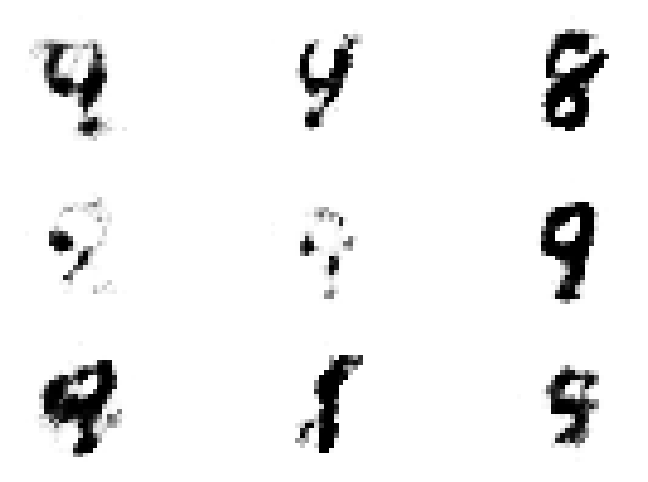

Epoch:410, D-Loss:0.354, D-Acc:95.000, G-Loss:3.133, Sigma:0.0983
Epoch:411, D-Loss:0.381, D-Acc:93.333, G-Loss:3.192, Sigma:0.0983
Epoch:412, D-Loss:0.496, D-Acc:93.333, G-Loss:2.139, Sigma:0.0983
Epoch:413, D-Loss:0.697, D-Acc:86.667, G-Loss:2.898, Sigma:0.0983
Epoch:414, D-Loss:0.567, D-Acc:85.000, G-Loss:2.934, Sigma:0.0983


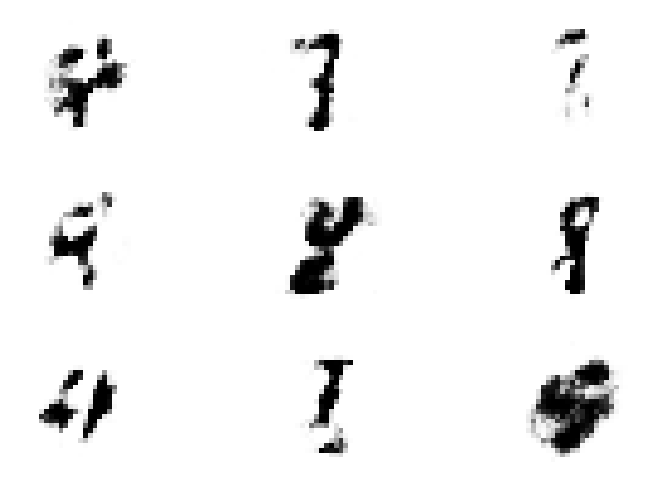

Epoch:415, D-Loss:0.682, D-Acc:81.667, G-Loss:2.768, Sigma:0.0983
Epoch:416, D-Loss:0.760, D-Acc:80.000, G-Loss:2.619, Sigma:0.0983
Epoch:417, D-Loss:0.464, D-Acc:91.667, G-Loss:2.988, Sigma:0.0982
Epoch:418, D-Loss:0.287, D-Acc:95.000, G-Loss:2.580, Sigma:0.0982
Epoch:419, D-Loss:0.662, D-Acc:86.667, G-Loss:2.868, Sigma:0.0982


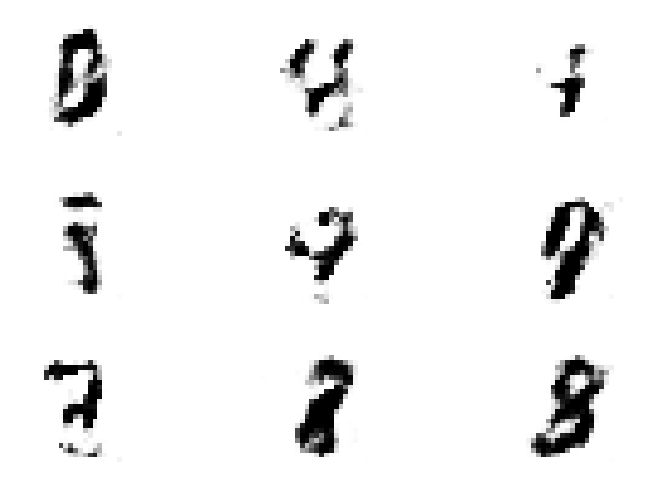

Epoch:420, D-Loss:0.460, D-Acc:90.000, G-Loss:2.963, Sigma:0.0982
Epoch:421, D-Loss:0.457, D-Acc:93.333, G-Loss:2.754, Sigma:0.0982
Epoch:422, D-Loss:0.511, D-Acc:88.333, G-Loss:3.137, Sigma:0.0982
Epoch:423, D-Loss:0.328, D-Acc:93.333, G-Loss:2.512, Sigma:0.0982
Epoch:424, D-Loss:0.464, D-Acc:88.333, G-Loss:2.842, Sigma:0.0982


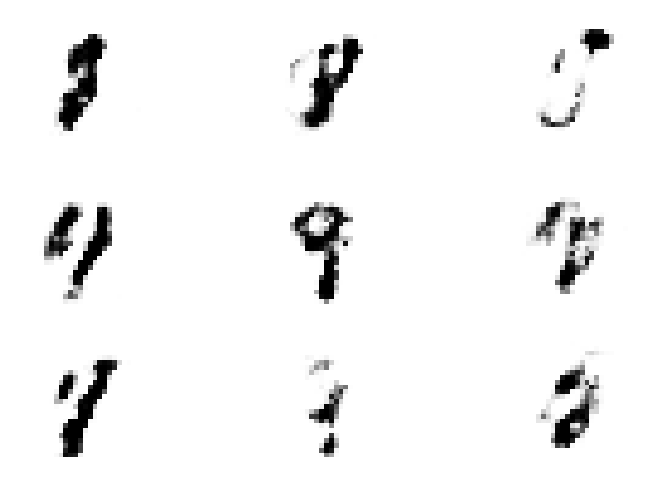

Epoch:425, D-Loss:0.655, D-Acc:81.667, G-Loss:2.539, Sigma:0.0982
Epoch:426, D-Loss:0.504, D-Acc:88.333, G-Loss:2.671, Sigma:0.0982
Epoch:427, D-Loss:0.315, D-Acc:91.667, G-Loss:3.028, Sigma:0.0982
Epoch:428, D-Loss:0.486, D-Acc:85.000, G-Loss:2.485, Sigma:0.0982
Epoch:429, D-Loss:0.543, D-Acc:88.333, G-Loss:2.683, Sigma:0.0982


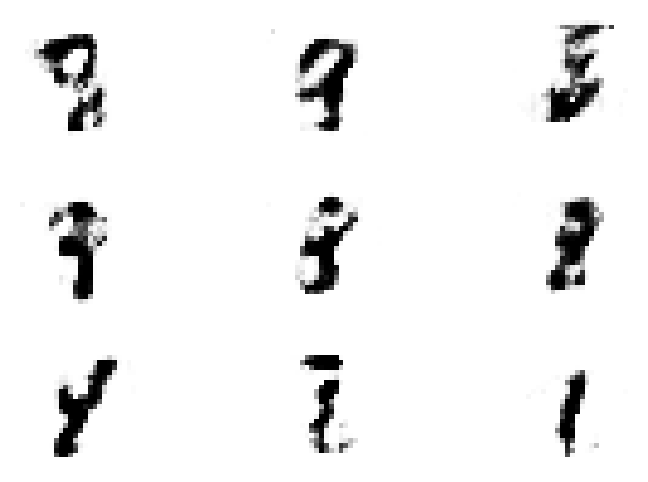

Epoch:430, D-Loss:0.385, D-Acc:95.000, G-Loss:3.131, Sigma:0.0982
Epoch:431, D-Loss:0.405, D-Acc:88.333, G-Loss:3.054, Sigma:0.0982
Epoch:432, D-Loss:0.599, D-Acc:90.000, G-Loss:3.207, Sigma:0.0982
Epoch:433, D-Loss:0.643, D-Acc:90.000, G-Loss:3.075, Sigma:0.0982
Epoch:434, D-Loss:0.440, D-Acc:93.333, G-Loss:3.324, Sigma:0.0982


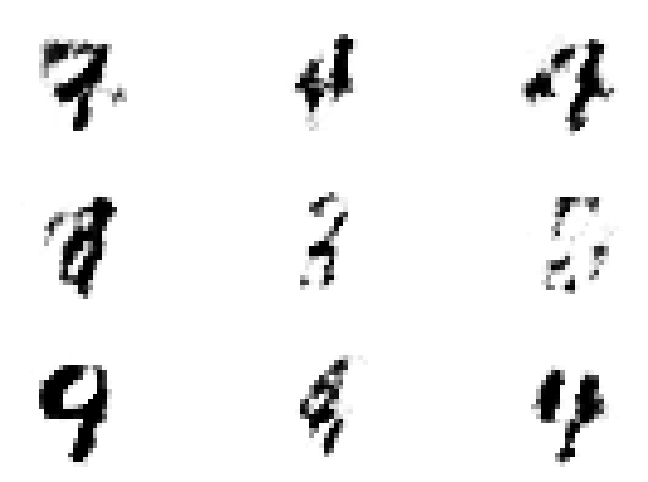

Epoch:435, D-Loss:0.394, D-Acc:90.000, G-Loss:2.680, Sigma:0.0982
Epoch:436, D-Loss:0.445, D-Acc:88.333, G-Loss:3.202, Sigma:0.0982
Epoch:437, D-Loss:0.467, D-Acc:90.000, G-Loss:3.112, Sigma:0.0982
Epoch:438, D-Loss:0.355, D-Acc:95.000, G-Loss:2.763, Sigma:0.0982
Epoch:439, D-Loss:0.476, D-Acc:90.000, G-Loss:3.271, Sigma:0.0982


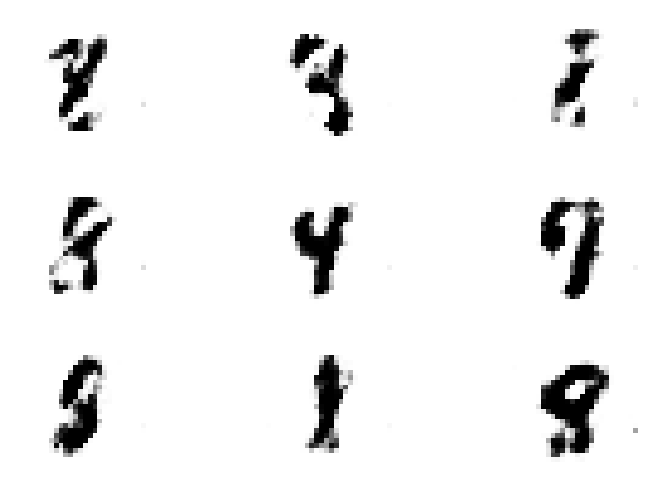

Epoch:440, D-Loss:0.389, D-Acc:88.333, G-Loss:3.200, Sigma:0.0982
Epoch:441, D-Loss:0.375, D-Acc:96.667, G-Loss:3.100, Sigma:0.0982
Epoch:442, D-Loss:0.522, D-Acc:90.000, G-Loss:3.063, Sigma:0.0982
Epoch:443, D-Loss:0.428, D-Acc:93.333, G-Loss:2.892, Sigma:0.0982
Epoch:444, D-Loss:0.382, D-Acc:91.667, G-Loss:3.253, Sigma:0.0982


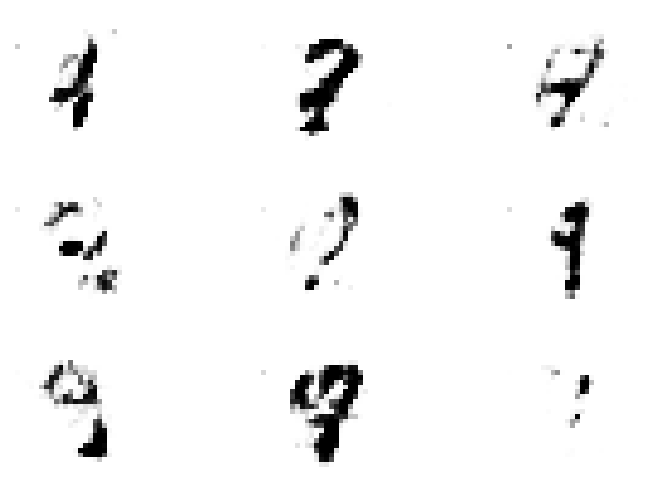

Epoch:445, D-Loss:0.472, D-Acc:91.667, G-Loss:2.872, Sigma:0.0982
Epoch:446, D-Loss:0.385, D-Acc:93.333, G-Loss:2.794, Sigma:0.0982
Epoch:447, D-Loss:0.406, D-Acc:91.667, G-Loss:3.063, Sigma:0.0982
Epoch:448, D-Loss:0.314, D-Acc:95.000, G-Loss:3.051, Sigma:0.0982
Epoch:449, D-Loss:0.609, D-Acc:85.000, G-Loss:3.238, Sigma:0.0982


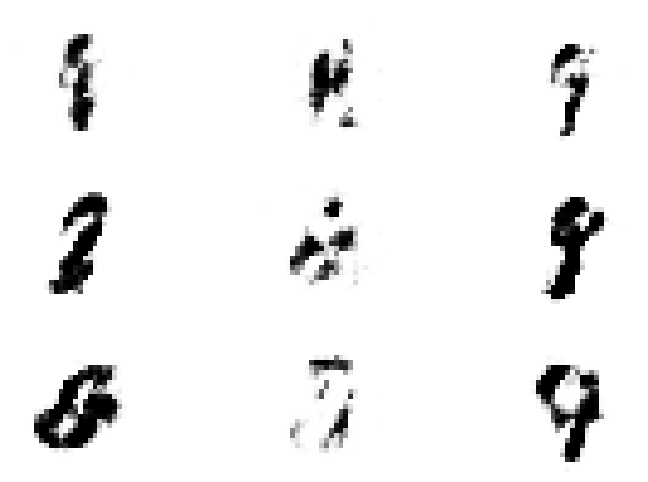

Epoch:450, D-Loss:0.679, D-Acc:90.000, G-Loss:2.966, Sigma:0.0982
Epoch:451, D-Loss:0.532, D-Acc:88.333, G-Loss:3.256, Sigma:0.0982
Epoch:452, D-Loss:0.493, D-Acc:90.000, G-Loss:3.280, Sigma:0.0982
Epoch:453, D-Loss:0.336, D-Acc:93.333, G-Loss:3.448, Sigma:0.0982
Epoch:454, D-Loss:0.398, D-Acc:91.667, G-Loss:3.413, Sigma:0.0982


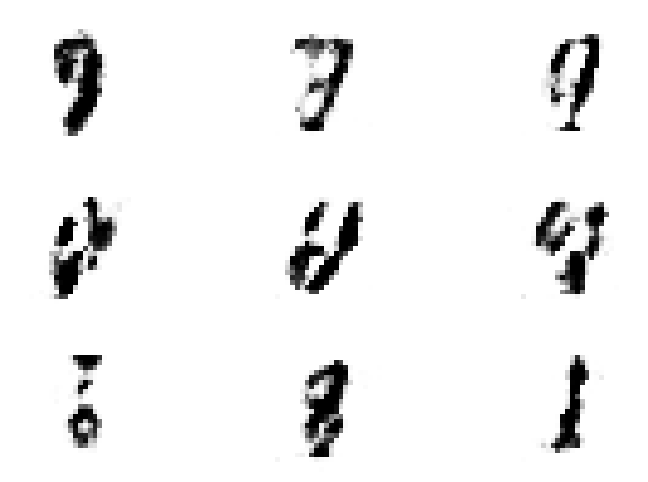

Epoch:455, D-Loss:0.373, D-Acc:93.333, G-Loss:2.825, Sigma:0.0982
Epoch:456, D-Loss:0.308, D-Acc:93.333, G-Loss:3.270, Sigma:0.0982
Epoch:457, D-Loss:0.469, D-Acc:91.667, G-Loss:3.241, Sigma:0.0981
Epoch:458, D-Loss:0.350, D-Acc:91.667, G-Loss:2.745, Sigma:0.0981
Epoch:459, D-Loss:0.453, D-Acc:90.000, G-Loss:2.751, Sigma:0.0981


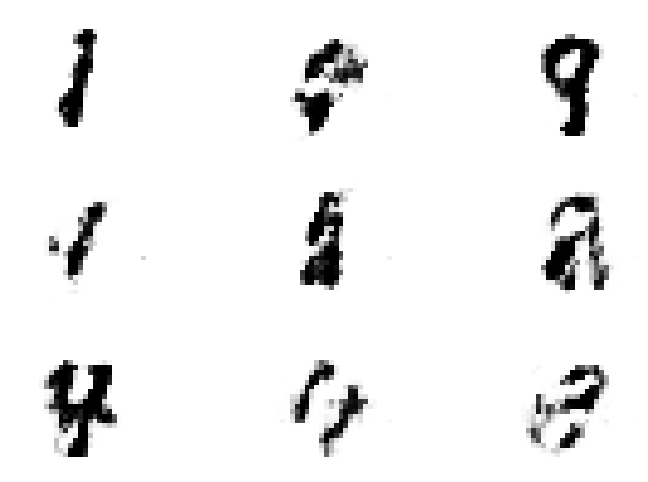

Epoch:460, D-Loss:0.512, D-Acc:93.333, G-Loss:2.769, Sigma:0.0981
Epoch:461, D-Loss:0.527, D-Acc:91.667, G-Loss:2.489, Sigma:0.0981
Epoch:462, D-Loss:0.422, D-Acc:91.667, G-Loss:2.796, Sigma:0.0981
Epoch:463, D-Loss:0.262, D-Acc:96.667, G-Loss:3.564, Sigma:0.0981
Epoch:464, D-Loss:0.355, D-Acc:91.667, G-Loss:2.698, Sigma:0.0981


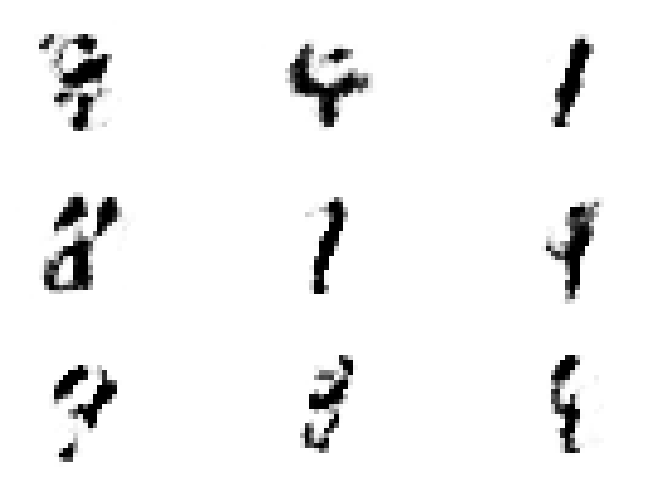

Epoch:465, D-Loss:0.432, D-Acc:90.000, G-Loss:2.962, Sigma:0.0981
Epoch:466, D-Loss:0.410, D-Acc:95.000, G-Loss:3.122, Sigma:0.0981
Epoch:467, D-Loss:0.478, D-Acc:85.000, G-Loss:2.892, Sigma:0.0981
Epoch:468, D-Loss:0.392, D-Acc:90.000, G-Loss:3.001, Sigma:0.0981
Epoch:469, D-Loss:0.194, D-Acc:98.333, G-Loss:3.335, Sigma:0.0981


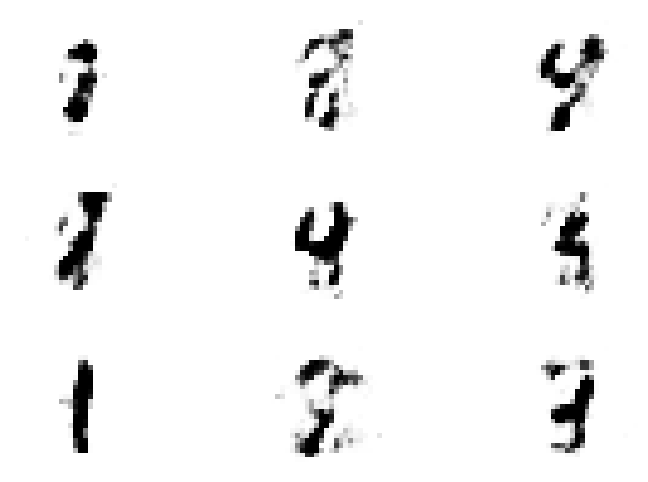

Epoch:470, D-Loss:0.361, D-Acc:91.667, G-Loss:3.121, Sigma:0.0981
Epoch:471, D-Loss:0.623, D-Acc:91.667, G-Loss:2.669, Sigma:0.0981
Epoch:472, D-Loss:0.397, D-Acc:90.000, G-Loss:2.824, Sigma:0.0981
Epoch:473, D-Loss:0.369, D-Acc:93.333, G-Loss:3.465, Sigma:0.0981
Epoch:474, D-Loss:0.431, D-Acc:88.333, G-Loss:3.287, Sigma:0.0981


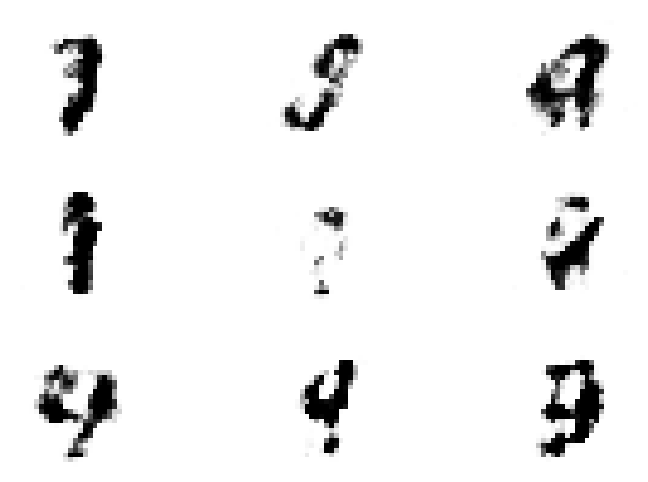

Epoch:475, D-Loss:0.322, D-Acc:93.333, G-Loss:3.385, Sigma:0.0981
Epoch:476, D-Loss:0.518, D-Acc:90.000, G-Loss:2.860, Sigma:0.0981
Epoch:477, D-Loss:0.448, D-Acc:88.333, G-Loss:2.966, Sigma:0.0981
Epoch:478, D-Loss:0.475, D-Acc:93.333, G-Loss:3.142, Sigma:0.0981
Epoch:479, D-Loss:0.402, D-Acc:90.000, G-Loss:2.942, Sigma:0.0981


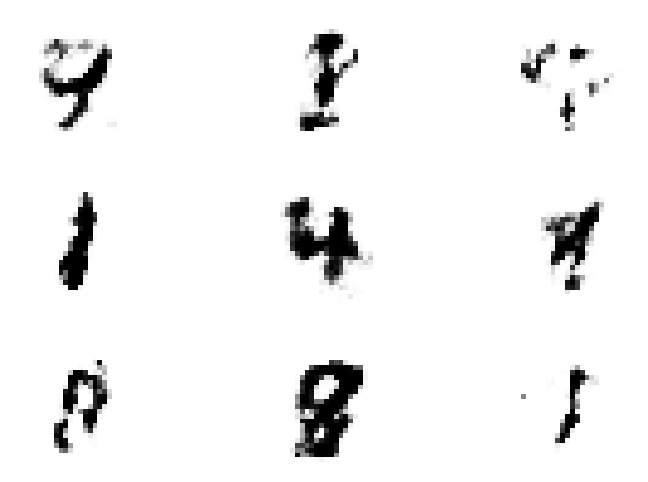

Epoch:480, D-Loss:0.304, D-Acc:95.000, G-Loss:3.017, Sigma:0.0981
Epoch:481, D-Loss:0.520, D-Acc:86.667, G-Loss:3.259, Sigma:0.0981
Epoch:482, D-Loss:0.399, D-Acc:93.333, G-Loss:3.091, Sigma:0.0980
Epoch:483, D-Loss:0.284, D-Acc:96.667, G-Loss:2.943, Sigma:0.0980
Epoch:484, D-Loss:0.337, D-Acc:93.333, G-Loss:3.229, Sigma:0.0980


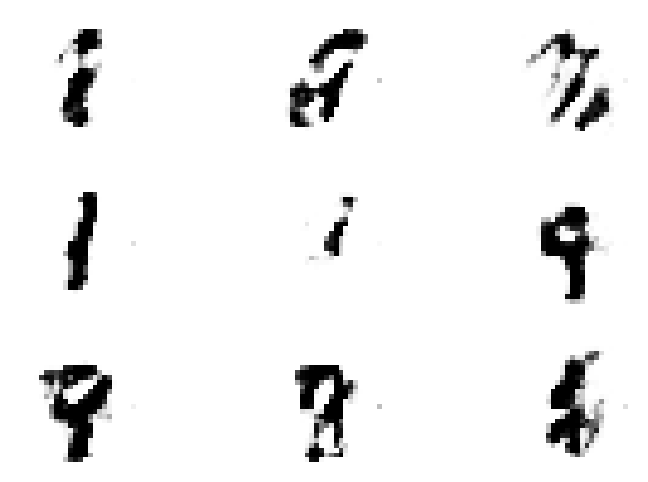

Epoch:485, D-Loss:0.169, D-Acc:100.000, G-Loss:3.042, Sigma:0.0980
Epoch:486, D-Loss:0.352, D-Acc:95.000, G-Loss:2.971, Sigma:0.0980
Epoch:487, D-Loss:0.265, D-Acc:95.000, G-Loss:3.250, Sigma:0.0980
Epoch:488, D-Loss:0.353, D-Acc:91.667, G-Loss:2.804, Sigma:0.0980
Epoch:489, D-Loss:0.407, D-Acc:95.000, G-Loss:2.970, Sigma:0.0980


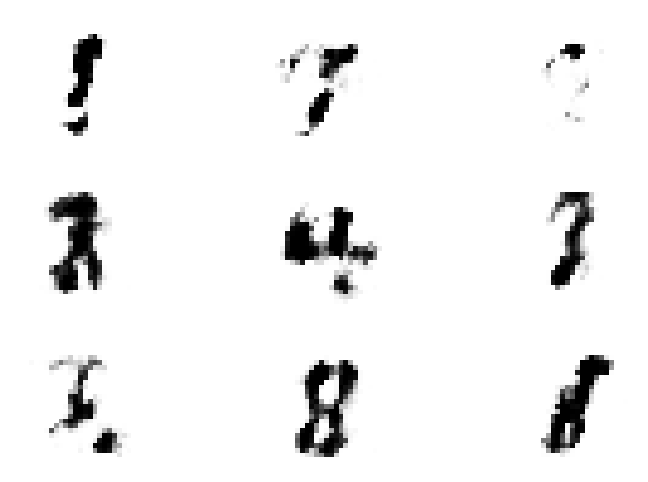

Epoch:490, D-Loss:0.259, D-Acc:95.000, G-Loss:3.264, Sigma:0.0980
Epoch:491, D-Loss:0.332, D-Acc:91.667, G-Loss:3.449, Sigma:0.0980
Epoch:492, D-Loss:0.517, D-Acc:86.667, G-Loss:3.445, Sigma:0.0980
Epoch:493, D-Loss:0.332, D-Acc:88.333, G-Loss:3.350, Sigma:0.0980
Epoch:494, D-Loss:0.384, D-Acc:93.333, G-Loss:3.678, Sigma:0.0980


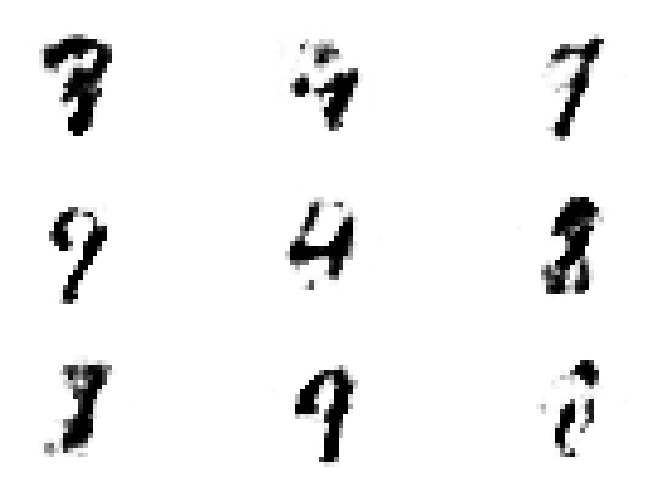

Epoch:495, D-Loss:0.232, D-Acc:95.000, G-Loss:3.993, Sigma:0.0980
Epoch:496, D-Loss:0.302, D-Acc:93.333, G-Loss:3.371, Sigma:0.0980
Epoch:497, D-Loss:0.292, D-Acc:95.000, G-Loss:3.891, Sigma:0.0980
Epoch:498, D-Loss:0.516, D-Acc:93.333, G-Loss:2.787, Sigma:0.0980
Epoch:499, D-Loss:0.404, D-Acc:91.667, G-Loss:2.781, Sigma:0.0980


In [35]:
# 记录损失和sigma值
losses_d = []
losses_g = []
sigma_values = []
#wasserstein_distances = []

# 训练循环
for i in range(epochs):
    if i % 5 == 0:
        show_generator_results(generator)
    
    for j in range(steps):
        # 训练判别器
        discriminator.zero_grad()
        
        # 真实样本
        real_samples = get_real_samples(batch_size//2)
        real_labels = torch.ones(batch_size//2, 1, device=device)
        real_output, _ = discriminator(real_samples)  # 提取判别器输出
        d_loss_real = criterion(real_output, real_labels)
        
        # 假样本
        fake_samples = get_fake_samples(generator, batch_size//2)
        fake_labels = torch.zeros(batch_size//2, 1, device=device)
        fake_output, _ = discriminator(fake_samples)  # 提取判别器输出
        d_loss_fake = criterion(fake_output, fake_labels)
        
        # 判别器总损失
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()
        
        # 记录sigma值（从fake_output中提取sigma值是不正确的，应该重新调用discriminator来获取sigma）
        _, sigma = discriminator(fake_samples.detach())  # 使用detach()避免影响梯度计算
        sigma_values.append(sigma.item())
      
        # 计算判别器准确度
        d_acc = (torch.sum((real_output > 0.5).float()) + 
                torch.sum((fake_output < 0.5).float())) / (batch_size)

        # 训练生成器
        generator.zero_grad()
        
        #生成新的假样本
        noise = torch.randn(batch_size, 100, device=device)
        fake_samples = generator(noise)
       
        # 让判别器认为这些是真实样本
        fake_output, _ = discriminator(fake_samples)
        g_loss = criterion(fake_output, torch.ones(batch_size, 1, device=device))
  
        g_loss.backward()
        optimizer_g.step()
        
        # 记录损失
        losses_d.append(d_loss.item())
        losses_g.append(g_loss.item())

    print(f"Epoch:{i}, D-Loss:{d_loss.item():.3f}, D-Acc:{d_acc.item()*100:.3f}, G-Loss:{g_loss.item():.3f}, Sigma:{sigma.item():.4f}")

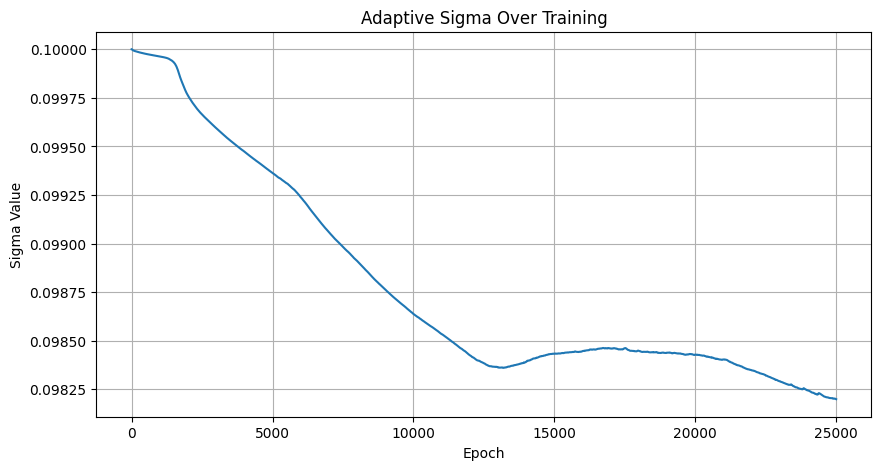

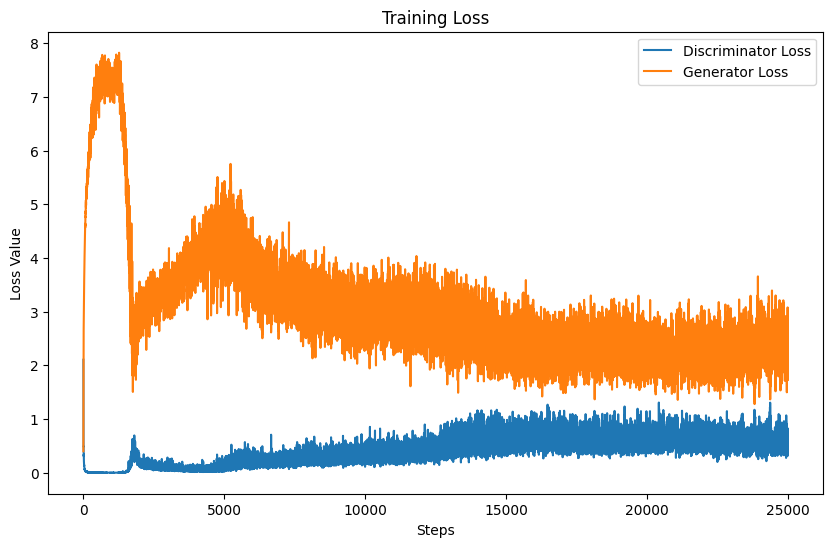

In [16]:
# 绘制sigma值的变化
plt.figure(figsize=(10, 5))
plt.plot(sigma_values)
plt.xlabel('Epoch')
plt.ylabel('Sigma Value')
plt.title('Adaptive Sigma Over Training')
plt.grid(True)
plt.show()

# 绘制损失曲线
steps = [i for i in range(len(losses_d))]
plt.figure(figsize=(10, 6))
plt.plot(steps, losses_d, label='Discriminator Loss')
plt.plot(steps, losses_g, label='Generator Loss')
plt.xlabel('Steps')
plt.ylabel('Loss Value')
plt.title("Training Loss")
plt.legend()
plt.show()

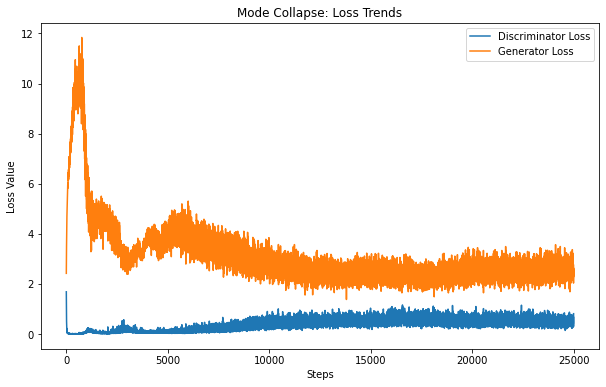

In [8]:
# 绘制损失曲线
steps = [i for i in range(len(losses_d))]
plt.figure(figsize=(10, 6))
plt.plot(losses_d)
plt.plot(losses_g)
plt.xlabel('Steps')
plt.ylabel('Loss Value')
plt.title("Mode Collapse: Loss Trends")
plt.legend(['Discriminator Loss', 'Generator Loss'])
plt.show()

# 绘制Wasserstein距离曲线
#plt.figure(figsize=(10, 6))
#plt.plot(range(0, len(wasserstein_distances)*10, 10), wasserstein_distances, label='Wasserstein Distance')
#plt.xlabel('Steps (every 10 steps)')
#plt.ylabel('Wasserstein Distance')
#plt.title("GAN Training: Wasserstein Distance")
#plt.legend()
#plt.show()